In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the reference data
df = pd.read_csv('full_metrics_data_300peaks.csv', header=None)
df.columns = ['function', 'peak_id', 't', 'mag', 'M_coh', 'R_comp']

# Check the structure
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nFunction counts:")
print(df['function'].value_counts())


Dataset shape: (301, 6)

First few rows:
 function peak_id t mag M_coh \
0 Function Peak_Index t_value Peak_Magnitude M_coh 
1 ζ 0 9654.0 15.710188352775901 2.001095276872932 
2 ζ 1 9826.0 15.661042671425465 2.03428685255509 
3 ζ 2 7578.0 15.417136197372878 1.8312669723566861 
4 ζ 3 6726.0 15.22203910895705 1.8359122120095477 
5 ζ 4 8476.0 15.122170302935023 1.9420321656472126 
6 ζ 5 8647.0 15.057177432153987 2.0035325074962387 
7 ζ 6 4478.0 14.597083731039843 1.7294654650934174 
8 ζ 7 8956.0 14.437149928026123 1.9117665561721042 
9 ζ 8 9128.0 14.28715705487269 1.921840526321203 

 R_comp 
0 R_comp 
1 0.008279477439853963 
2 0.008303449331362732 
3 0.005041247469444545 
4 0.005335710626818154 
5 0.011078765396520075 
6 0.012424472389836563 
7 0.003483566780311066 
8 0.005275287984615083 
9 0.004859941213569884 

Function counts:
function
ζ 50
L(s,χ₄) mod5 50
f_rand 50
L(s,χ_4) mod4 50
L_DH 50
f_fully_rand 50
Function 1
Name: count, dtype: int64


In [2]:

# Remove header row and convert to numeric
df = df[df['function'] != 'Function'].copy()
df['t'] = pd.to_numeric(df['t'])
df['mag'] = pd.to_numeric(df['mag'])
df['M_coh'] = pd.to_numeric(df['M_coh'])
df['R_comp'] = pd.to_numeric(df['R_comp'])

print("Cleaned dataset shape:", df.shape)
print("\nFunction counts:")
print(df['function'].value_counts())
print("\nSummary statistics for reference L_DH:")
print(df[df['function'] == 'L_DH'][['M_coh', 'R_comp', 'mag']].describe())


Cleaned dataset shape: (300, 6)

Function counts:
function
ζ 50
L(s,χ₄) mod5 50
f_rand 50
L_DH 50
L(s,χ_4) mod4 50
f_fully_rand 50
Name: count, dtype: int64

Summary statistics for reference L_DH:
 M_coh R_comp mag
count 50.000000 50.000000 50.000000
mean 1.994484 0.018543 8.637994
std 0.184537 0.002294 0.590861
min 1.373964 0.014703 7.911783
25% 1.900621 0.016807 8.100826
50% 2.041589 0.018281 8.523960
75% 2.138045 0.020029 9.056598
max 2.227967 0.024894 10.267795


In [3]:

# Now let's implement the canonical L_DH function based on the specification
# From the PDF page 5:
# χ is the primitive complex character modulo 5 of order 4:
# χ(1) = 1, χ(2) = i, χ(3) = -i, χ(4) = -1, χ(0) = 0
# κ = (√5 - 1) / (2√(5(√5 - 1)))
# L_DH(s) = ((1 - iκ)/2) · L(s,χ) + ((1 + iκ)/2) · L(s,χ̄)

import numpy as np
from numba import jit

# Define kappa
sqrt5 = np.sqrt(5)
kappa = (sqrt5 - 1) / (2 * np.sqrt(5 * (sqrt5 - 1)))
print(f"κ = {kappa}")
print(f"κ ≈ {kappa:.10f}")

# Define the character χ modulo 5
def chi_mod5(n):
 """Complex character modulo 5 of order 4"""
 n_mod = n % 5
 if n_mod == 0:
 return 0.0 + 0.0j
 elif n_mod == 1:
 return 1.0 + 0.0j
 elif n_mod == 2:
 return 0.0 + 1.0j # i
 elif n_mod == 3:
 return 0.0 - 1.0j # -i
 elif n_mod == 4:
 return -1.0 + 0.0j
 
def chi_bar_mod5(n):
 """Complex conjugate of χ"""
 return np.conj(chi_mod5(n))

# Function to check if n is squarefree
def is_squarefree(n):
 """Check if n is squarefree"""
 if n <= 1:
 return n == 1
 i = 2
 while i * i <= n:
 if n % (i * i) == 0:
 return False
 i += 1
 return True

# Compute the coefficients a_n for L_DH
def compute_L_DH_coefficients(N_max):
 """Compute coefficients a_n for canonical L_DH up to N_max"""
 a_n = np.zeros(N_max + 1, dtype=np.complex128)
 
 for n in range(1, N_max + 1):
 if is_squarefree(n):
 chi_n = chi_mod5(n)
 chi_bar_n = chi_bar_mod5(n)
 # L_DH coefficients: ((1-iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n)
 a_n[n] = ((1 - 1j*kappa)/2) * chi_n + ((1 + 1j*kappa)/2) * chi_bar_n
 else:
 a_n[n] = 0.0 + 0.0j
 
 return a_n

# Test with small values
print("\nTest coefficients for n=1 to 10:")
for n in range(1, 11):
 sf = is_squarefree(n)
 chi_n = chi_mod5(n)
 chi_bar_n = chi_bar_mod5(n)
 if sf:
 a_n = ((1 - 1j*kappa)/2) * chi_n + ((1 + 1j*kappa)/2) * chi_bar_n
 else:
 a_n = 0.0 + 0.0j
 print(f"n={n}, squarefree={sf}, χ(n)={chi_n}, a_n={a_n}")


κ = 0.24860289393928922
κ ≈ 0.2486028939

Test coefficients for n=1 to 10:
n=1, squarefree=True, χ(n)=(1+0j), a_n=(1+0j)
n=2, squarefree=True, χ(n)=1j, a_n=(0.24860289393928922+0j)
n=3, squarefree=True, χ(n)=-1j, a_n=(-0.24860289393928922+0j)
n=4, squarefree=False, χ(n)=(-1+0j), a_n=0j
n=5, squarefree=True, χ(n)=0j, a_n=0j
n=6, squarefree=True, χ(n)=(1+0j), a_n=(1+0j)
n=7, squarefree=True, χ(n)=1j, a_n=(0.24860289393928922+0j)
n=8, squarefree=False, χ(n)=-1j, a_n=0j
n=9, squarefree=False, χ(n)=(-1+0j), a_n=0j
n=10, squarefree=True, χ(n)=0j, a_n=0j


In [4]:

# Now let's validate by computing L_DH at the known off-line zeros
# From the PDF, the known zeros are:
# σ = 0.8085, t = 85.70
# σ = 0.6508, t = 114.16
# σ = 0.5744, t = 166.48
# σ = 0.7243, t = 176.70

def compute_L_DH_at_point(s, N_max):
 """
 Compute L_DH(s) at a given point s = sigma + it
 using Kahan compensated summation for accuracy
 """
 sigma = s.real
 t = s.imag
 
 # Compute coefficients
 a_n = compute_L_DH_coefficients(N_max)
 
 # Compute sum with Kahan summation
 sum_val = 0.0 + 0.0j
 c = 0.0 + 0.0j # compensation term
 
 for n in range(1, N_max + 1):
 if a_n[n] != 0:
 term = a_n[n] / (n ** s)
 y = term - c
 temp = sum_val + y
 c = (temp - sum_val) - y
 sum_val = temp
 
 return sum_val

# Test at the four known zeros with N=10^6 (will use 10^7 later for final validation)
print("Testing canonical L_DH at known off-line zeros (N=10^6):")
print("This will take a few seconds...\n")

known_zeros = [
 (0.8085, 85.70),
 (0.6508, 114.16),
 (0.5744, 166.48),
 (0.7243, 176.70)
]

N_test = 10**6
results = []

for sigma, t in known_zeros:
 s = complex(sigma, t)
 L_val = compute_L_DH_at_point(s, N_test)
 magnitude = abs(L_val)
 print(f"σ={sigma:.4f}, t={t:.2f}: L_DH(s) = {L_val}, |L_DH(s)| = {magnitude:.2e}")
 results.append((sigma, t, magnitude))


Testing canonical L_DH at known off-line zeros (N=10^6):
This will take a few seconds...



σ=0.8085, t=85.70: L_DH(s) = (0.03554180215489358+0.01552400973996982j), |L_DH(s)| = 3.88e-02


σ=0.6508, t=114.16: L_DH(s) = (0.02310448124950803-0.011218737308910133j), |L_DH(s)| = 2.57e-02


σ=0.5744, t=166.48: L_DH(s) = (0.013008754816055238+0.014689156461645205j), |L_DH(s)| = 1.96e-02


σ=0.7243, t=176.70: L_DH(s) = (0.02216197531995157-0.012107157338353462j), |L_DH(s)| = 2.53e-02


In [5]:

# The values are not close to zero - this suggests we might have an error
# Let me check the formula more carefully
# The issue might be with how we're computing the character

# Let's verify the character definition more carefully
# χ(2) = i means χ(2) should give i
# Let's also check if the issue is with the formula itself

# Actually, let me re-check the coefficients formula
# From equation (2) in the PDF:
# a_n = ((1-iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n)

# Let's expand this:
# For n=1: χ(1)=1, χ̄(1)=1
# a_1 = ((1-iκ)/2)·1 + ((1+iκ)/2)·1 = (1-iκ+1+iκ)/2 = 2/2 = 1 ✓

# For n=2: χ(2)=i, χ̄(2)=-i
# a_2 = ((1-iκ)/2)·i + ((1+iκ)/2)·(-i) = (i-i²κ-i-i²κ)/2 = (i+κ-i+κ)/2 = 2κ/2 = κ
# But I got a_2 = 0.2486... which equals κ ✓

# Wait, let me check a_2 again more carefully:
print("Detailed check of a_2:")
chi_2 = 0.0 + 1.0j # i
chi_bar_2 = 0.0 - 1.0j # -i
term1 = ((1 - 1j*kappa)/2) * chi_2
term2 = ((1 + 1j*kappa)/2) * chi_bar_2
a_2_calc = term1 + term2
print(f"χ(2) = {chi_2}")
print(f"χ̄(2) = {chi_bar_2}")
print(f"term1 = ((1-iκ)/2)·i = {term1}")
print(f"term2 = ((1+iκ)/2)·(-i) = {term2}")
print(f"a_2 = {a_2_calc}")
print(f"Expected: a_2 should have imaginary part from terms")

# Let me recalculate manually:
# ((1-iκ)/2)·i = (i - i²κ)/2 = (i + κ)/2
# ((1+iκ)/2)·(-i) = (-i - i²κ)/2 = (-i + κ)/2
# Sum = (i + κ - i + κ)/2 = 2κ/2 = κ (real)
print(f"\nManual: ((1-iκ)/2)·i = (i+κ)/2 = {(1j + kappa)/2}")
print(f"Manual: ((1+iκ)/2)·(-i) = (-i+κ)/2 = {(-1j + kappa)/2}")
print(f"Sum = {(1j + kappa)/2 + (-1j + kappa)/2}")


Detailed check of a_2:
χ(2) = 1j
χ̄(2) = -1j
term1 = ((1-iκ)/2)·i = (0.12430144696964461+0.5j)
term2 = ((1+iκ)/2)·(-i) = (0.12430144696964461-0.5j)
a_2 = (0.24860289393928922+0j)
Expected: a_2 should have imaginary part from terms

Manual: ((1-iκ)/2)·i = (i+κ)/2 = (0.12430144696964461+0.5j)
Manual: ((1+iκ)/2)·(-i) = (-i+κ)/2 = (0.12430144696964461-0.5j)
Sum = (0.24860289393928922+0j)


In [6]:

# That's too slow. Let me optimize with numba
from numba import jit
import numpy as np

# Precompute character values for speed
def precompute_chi_mod5(N_max):
 """Precompute χ(n) for n=1 to N_max"""
 chi = np.zeros(N_max + 1, dtype=np.complex128)
 for n in range(1, N_max + 1):
 n_mod = n % 5
 if n_mod == 1:
 chi[n] = 1.0 + 0.0j
 elif n_mod == 2:
 chi[n] = 0.0 + 1.0j
 elif n_mod == 3:
 chi[n] = 0.0 - 1.0j
 elif n_mod == 4:
 chi[n] = -1.0 + 0.0j
 # else chi[n] = 0 (already initialized)
 return chi

@jit(nopython=True)
def is_squarefree_fast(n):
 """Fast squarefree check"""
 if n <= 1:
 return n == 1
 i = 2
 while i * i <= n:
 if n % (i * i) == 0:
 return False
 i += 1
 return True

@jit(nopython=True)
def compute_L_DH_optimized(sigma, t, chi_vals, kappa_val, N_max):
 """Optimized computation of L_DH(sigma + it)"""
 sum_real = 0.0
 sum_imag = 0.0
 c_real = 0.0
 c_imag = 0.0
 
 for n in range(1, N_max + 1):
 if not is_squarefree_fast(n):
 continue
 
 chi_n = chi_vals[n]
 if chi_n == 0.0 + 0.0j:
 continue
 
 # Compute a_n = ((1-iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n)
 chi_real = chi_n.real
 chi_imag = chi_n.imag
 
 # term1 = ((1-iκ)/2)·χ(n)
 # = (1/2 - iκ/2)·(chi_real + i·chi_imag)
 # = chi_real/2 - iκ·chi_real/2 + i·chi_imag/2 + i²κ·chi_imag/2
 # = (chi_real/2 + κ·chi_imag/2) + i(chi_imag/2 - κ·chi_real/2)
 term1_real = 0.5 * chi_real + 0.5 * kappa_val * chi_imag
 term1_imag = 0.5 * chi_imag - 0.5 * kappa_val * chi_real
 
 # term2 = ((1+iκ)/2)·χ̄(n)
 # = (1/2 + iκ/2)·(chi_real - i·chi_imag)
 # = chi_real/2 + iκ·chi_real/2 - i·chi_imag/2 + i²κ·(-chi_imag)/2
 # = (chi_real/2 - κ·chi_imag/2) + i(κ·chi_real/2 - chi_imag/2)
 term2_real = 0.5 * chi_real - 0.5 * kappa_val * chi_imag
 term2_imag = 0.5 * kappa_val * chi_real - 0.5 * chi_imag
 
 a_n_real = term1_real + term2_real
 a_n_imag = term1_imag + term2_imag
 
 # Compute n^(-s) = n^(-sigma - it) = n^(-sigma) * e^(-it·log(n))
 n_to_minus_sigma = n ** (-sigma)
 log_n = np.log(n)
 cos_val = np.cos(-t * log_n)
 sin_val = np.sin(-t * log_n)
 
 # n^(-s) = n^(-sigma) * (cos - it·log(n) + i·sin - it·log(n))
 n_inv_s_real = n_to_minus_sigma * cos_val
 n_inv_s_imag = n_to_minus_sigma * sin_val
 
 # a_n / n^s = (a_n_real + i·a_n_imag) * (n_inv_s_real + i·n_inv_s_imag)
 term_real = a_n_real * n_inv_s_real - a_n_imag * n_inv_s_imag
 term_imag = a_n_real * n_inv_s_imag + a_n_imag * n_inv_s_real
 
 # Kahan summation
 y_real = term_real - c_real
 y_imag = term_imag - c_imag
 temp_real = sum_real + y_real
 temp_imag = sum_imag + y_imag
 c_real = (temp_real - sum_real) - y_real
 c_imag = (temp_imag - sum_imag) - y_imag
 sum_real = temp_real
 sum_imag = temp_imag
 
 return sum_real, sum_imag

# Test with N=10^7
print("Precomputing character values for N=10^7...")
N_large = 10**7
chi_vals = precompute_chi_mod5(N_large)
print("Done. Now computing L_DH at first zero...")

sigma, t = 0.8085, 85.70
sum_r, sum_i = compute_L_DH_optimized(sigma, t, chi_vals, kappa, N_large)
L_val = complex(sum_r, sum_i)
magnitude = abs(L_val)
print(f"\nσ={sigma:.4f}, t={t:.2f} with N=10^7:")
print(f" L_DH(s) = {L_val}")
print(f" |L_DH(s)| = {magnitude:.2e}")


Precomputing character values for N=10^7...


Done. Now computing L_DH at first zero...



σ=0.8085, t=85.70 with N=10^7:
 L_DH(s) = (0.28382990889742227+0.11576947078661476j)
 |L_DH(s)| = 3.07e-01


In [7]:

# The values are getting WORSE with larger N, not better. This suggests our 
# implementation might be incorrect. Let me reconsider the definition.

# Wait - I should check: are these the zeros of L_DH or zeros of L(s,χ)?
# Let me look at the literature more carefully.

# Actually, let me try computing just L(s, χ) at these points to see if they
# are zeros of the primitive character Dirichlet L-function

@jit(nopython=True)
def compute_L_chi_optimized(sigma, t, chi_vals, N_max):
 """Compute L(s, χ) where χ is the character mod 5"""
 sum_real = 0.0
 sum_imag = 0.0
 
 for n in range(1, N_max + 1):
 chi_n = chi_vals[n]
 if chi_n == 0.0 + 0.0j:
 continue
 
 chi_real = chi_n.real
 chi_imag = chi_n.imag
 
 # Compute n^(-s)
 n_to_minus_sigma = n ** (-sigma)
 log_n = np.log(n)
 cos_val = np.cos(-t * log_n)
 sin_val = np.sin(-t * log_n)
 
 n_inv_s_real = n_to_minus_sigma * cos_val
 n_inv_s_imag = n_to_minus_sigma * sin_val
 
 # χ(n) / n^s
 term_real = chi_real * n_inv_s_real - chi_imag * n_inv_s_imag
 term_imag = chi_real * n_inv_s_imag + chi_imag * n_inv_s_real
 
 sum_real += term_real
 sum_imag += term_imag
 
 return sum_real, sum_imag

print("Testing L(s, χ) at the purported zero locations:")
for sigma, t in known_zeros:
 sum_r, sum_i = compute_L_chi_optimized(sigma, t, chi_vals, 10**6)
 L_chi = complex(sum_r, sum_i)
 print(f"σ={sigma:.4f}, t={t:6.2f}: L(s,χ) = {L_chi}, |L(s,χ)| = {abs(L_chi):.2e}")


Testing L(s, χ) at the purported zero locations:
σ=0.8085, t= 85.70: L(s,χ) = (0.3387807895589646-0.6147130019656155j), |L(s,χ)| = 7.02e-01
σ=0.6508, t=114.16: L(s,χ) = (0.17950989460161637-0.3855559698107411j), |L(s,χ)| = 4.25e-01


σ=0.5744, t=166.48: L(s,χ) = (0.33724544142759677-0.27218766419805757j), |L(s,χ)| = 4.33e-01
σ=0.7243, t=176.70: L(s,χ) = (-0.09217056541730535-0.5328428498444159j), |L(s,χ)| = 5.41e-01


In [8]:

# These are clearly not zeros of L(s,χ) either. Let me reconsider.
# Maybe the issue is that the zero locations need more precision, or there's 
# something wrong with my understanding.

# Let me check the papers cited. But first, let me verify that my character 
# implementation is actually primitive mod 5 and of order 4.

# Check: χ is primitive mod 5 means the conductor is 5
# χ has order 4 means χ^4 = χ₀ (principal character)
# χ(2) = i, so χ^4(2) = i^4 = 1 ✓

# Let me try a different approach: implement L_DH by computing the zeros from scratch
# Or better yet, let me check if maybe these are approximate zeros and we need
# to use more sophisticated methods (functional equation, etc.)

# Actually, I realize the issue: the published zero locations might be approximate,
# or there might be an issue with the precision of the sigma values.
# Let me try to search in a small neighborhood around the published locations

def find_minimum_in_region(t_center, sigma_range, N, chi_vals):
 """Search for minimum |L_DH| near a given t"""
 sigmas = np.linspace(sigma_range[0], sigma_range[1], 20)
 min_val = float('inf')
 best_sigma = None
 
 for sigma in sigmas:
 sum_r, sum_i = compute_L_DH_optimized(sigma, t_center, chi_vals, kappa, N)
 mag = np.sqrt(sum_r**2 + sum_i**2)
 if mag < min_val:
 min_val = mag
 best_sigma = sigma
 
 return best_sigma, min_val

print("Searching for minima near published zero locations:")
N_search = 10**6
for sigma_pub, t_pub in known_zeros:
 sigma_best, min_mag = find_minimum_in_region(t_pub, (sigma_pub - 0.05, sigma_pub + 0.05), 
 N_search, chi_vals)
 print(f"t={t_pub:6.2f}: published σ={sigma_pub:.4f}, best σ={sigma_best:.4f}, min |L_DH|={min_mag:.4e}")


Searching for minima near published zero locations:


t= 85.70: published σ=0.8085, best σ=0.7585, min |L_DH|=2.2308e-01


t=114.16: published σ=0.6508, best σ=0.6008, min |L_DH|=8.3350e-02


t=166.48: published σ=0.5744, best σ=0.5402, min |L_DH|=1.3108e-01


t=176.70: published σ=0.7243, best σ=0.6743, min |L_DH|=1.0505e-01


In [9]:

# Still not getting close to zero. Let me reconsider the definition entirely.
# Perhaps I'm misunderstanding the L_DH construction.

# Let me re-read the definition: the character χ should be "primitive complex 
# character modulo 5 of order 4"

# Wait - I should double-check the formula for the coefficients.
# The PDF says: L_DH(s) = ((1-iκ)/2)·L(s,χ) + ((1+iκ)/2)·L(s,χ̄)
# This means we're taking a LINEAR COMBINATION of two L-functions

# The coefficients of this linear combination are:
# a_n = ((1-iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n)

# BUT WAIT - maybe the formula should only apply to SQUAREFREE n?
# Let me check if L(s,χ) itself only has nonzero coefficients for squarefree n

# Actually, for a Dirichlet character, χ(n) is defined for all n.
# So L(s,χ) = Σ χ(n)/n^s for all n, not just squarefree n.

# But the instruction says "coefficients a_n must be set to zero for all 
# non-squarefree numbers n" - this is specific to L_DH!

# Let me reconsider: maybe the issue is that I should NOT be restricting
# to squarefree n? Let me try without that restriction

@jit(nopython=True)
def compute_L_DH_no_restriction(sigma, t, chi_vals, kappa_val, N_max):
 """Compute L_DH without squarefree restriction"""
 sum_real = 0.0
 sum_imag = 0.0
 
 for n in range(1, N_max + 1):
 chi_n = chi_vals[n]
 if chi_n == 0.0 + 0.0j:
 continue
 
 chi_real = chi_n.real
 chi_imag = chi_n.imag
 
 # Compute a_n coefficients
 term1_real = 0.5 * chi_real + 0.5 * kappa_val * chi_imag
 term1_imag = 0.5 * chi_imag - 0.5 * kappa_val * chi_real
 term2_real = 0.5 * chi_real - 0.5 * kappa_val * chi_imag
 term2_imag = 0.5 * kappa_val * chi_real - 0.5 * chi_imag
 
 a_n_real = term1_real + term2_real
 a_n_imag = term1_imag + term2_imag
 
 # Compute n^(-s)
 n_to_minus_sigma = n ** (-sigma)
 log_n = np.log(n)
 cos_val = np.cos(-t * log_n)
 sin_val = np.sin(-t * log_n)
 
 n_inv_s_real = n_to_minus_sigma * cos_val
 n_inv_s_imag = n_to_minus_sigma * sin_val
 
 # Product
 term_real = a_n_real * n_inv_s_real - a_n_imag * n_inv_s_imag
 term_imag = a_n_real * n_inv_s_imag + a_n_imag * n_inv_s_real
 
 sum_real += term_real
 sum_imag += term_imag
 
 return sum_real, sum_imag

print("Testing WITHOUT squarefree restriction:")
for sigma, t in known_zeros:
 sum_r, sum_i = compute_L_DH_no_restriction(sigma, t, chi_vals, kappa, 10**6)
 L_val = complex(sum_r, sum_i)
 print(f"σ={sigma:.4f}, t={t:6.2f}: L_DH = {L_val}, |L_DH| = {abs(L_val):.4e}")


Testing WITHOUT squarefree restriction:
σ=0.8085, t= 85.70: L_DH = (0.18723227917436064+0.04386220185428351j), |L_DH| = 1.9230e-01


σ=0.6508, t=114.16: L_DH = (0.1147763448709575+0.015486050469311494j), |L_DH| = 1.1582e-01
σ=0.5744, t=166.48: L_DH = (0.09680783375289745+0.0688071194146094j), |L_DH| = 1.1877e-01
σ=0.7243, t=176.70: L_DH = (0.13180492349433476-0.0665213407718968j), |L_DH| = 1.4764e-01


In [10]:

# Still not close to zero. There must be something fundamentally wrong with 
# my implementation. Let me go back to basics and check the reference more carefully.

# Let me try computing directly from the definition as a sum of two L-functions:
# L_DH(s) = ((1-iκ)/2)·L(s,χ) + ((1+iκ)/2)·L(s,χ̄)

@jit(nopython=True) 
def compute_two_L_functions(sigma, t, chi_vals, N_max):
 """Compute both L(s,χ) and L(s,χ̄)"""
 sum_chi_real = 0.0
 sum_chi_imag = 0.0
 sum_chibar_real = 0.0
 sum_chibar_imag = 0.0
 
 for n in range(1, N_max + 1):
 chi_n = chi_vals[n]
 if chi_n == 0.0 + 0.0j:
 continue
 
 # Compute n^(-s)
 n_to_minus_sigma = n ** (-sigma)
 log_n = np.log(n)
 cos_val = np.cos(-t * log_n)
 sin_val = np.sin(-t * log_n)
 n_inv_s_real = n_to_minus_sigma * cos_val
 n_inv_s_imag = n_to_minus_sigma * sin_val
 
 # L(s, χ) term: χ(n) / n^s
 chi_real = chi_n.real
 chi_imag = chi_n.imag
 term_real = chi_real * n_inv_s_real - chi_imag * n_inv_s_imag
 term_imag = chi_real * n_inv_s_imag + chi_imag * n_inv_s_real
 sum_chi_real += term_real
 sum_chi_imag += term_imag
 
 # L(s, χ̄) term: χ̄(n) / n^s (χ̄ is complex conjugate)
 chibar_real = chi_real
 chibar_imag = -chi_imag
 term_real = chibar_real * n_inv_s_real - chibar_imag * n_inv_s_imag
 term_imag = chibar_real * n_inv_s_imag + chibar_imag * n_inv_s_real
 sum_chibar_real += term_real
 sum_chibar_imag += term_imag
 
 return (sum_chi_real, sum_chi_imag, sum_chibar_real, sum_chibar_imag)

def compute_L_DH_from_L_functions(sigma, t, chi_vals, kappa_val, N_max):
 """Compute L_DH as linear combination"""
 L_chi_r, L_chi_i, L_chibar_r, L_chibar_i = compute_two_L_functions(sigma, t, chi_vals, N_max)
 
 # L_DH = ((1-iκ)/2)·L(s,χ) + ((1+iκ)/2)·L(s,χ̄)
 # coef1 = (1-iκ)/2
 coef1_real = 0.5
 coef1_imag = -0.5 * kappa_val
 
 # coef2 = (1+iκ)/2
 coef2_real = 0.5
 coef2_imag = 0.5 * kappa_val
 
 # term1 = coef1 * L_chi
 term1_real = coef1_real * L_chi_r - coef1_imag * L_chi_i
 term1_imag = coef1_real * L_chi_i + coef1_imag * L_chi_r
 
 # term2 = coef2 * L_chibar
 term2_real = coef2_real * L_chibar_r - coef2_imag * L_chibar_i
 term2_imag = coef2_real * L_chibar_i + coef2_imag * L_chibar_r
 
 # L_DH = term1 + term2
 L_DH_real = term1_real + term2_real
 L_DH_imag = term1_imag + term2_imag
 
 return complex(L_DH_real, L_DH_imag)

print("Computing L_DH as explicit linear combination of L(s,χ) and L(s,χ̄):")
for sigma, t in known_zeros:
 L_DH = compute_L_DH_from_L_functions(sigma, t, chi_vals, kappa, 10**6)
 print(f"σ={sigma:.4f}, t={t:6.2f}: L_DH = {L_DH}, |L_DH| = {abs(L_DH):.4e}")
 
# This should give the same result as before, just confirming the implementation


Computing L_DH as explicit linear combination of L(s,χ) and L(s,χ̄):
σ=0.8085, t= 85.70: L_DH = (0.023508577628083047+0.006186803600484014j), |L_DH| = 2.4309e-02
σ=0.6508, t=114.16: L_DH = (0.01507613803807712-0.0006068973286855739j), |L_DH| = 1.5088e-02


σ=0.5744, t=166.48: L_DH = (0.012035543728579179+0.0090336343348415j), |L_DH| = 1.5049e-02
σ=0.7243, t=176.70: L_DH = (0.01587604683279098-0.010840386057008822j), |L_DH| = 1.9224e-02


In [11]:

# Interesting! Now we're getting much smaller values (order 10^-2).
# This is different from my earlier calculation. Let me check what was different.

# The difference is that in my optimized version, I was computing the 
# coefficients term-by-term, but here I'm computing the full L-functions first
# and then combining them. These should be mathematically equivalent, but
# let me verify...

# Actually wait - in compute_L_DH_no_restriction, I was computing for ALL n,
# but in the primary dataset description it says:
# "For all L_DH variants... coefficients a_n must be set to zero for all 
# non-squarefree numbers n."

# So I need to modify the L-function computation to only include squarefree terms!

@jit(nopython=True)
def is_squarefree_arr(n):
 if n <= 1:
 return n == 1
 i = 2
 while i * i <= n:
 if n % (i * i) == 0:
 return False
 i += 1
 return True

@jit(nopython=True)
def compute_two_L_functions_squarefree(sigma, t, chi_vals, N_max):
 """Compute L(s,χ) and L(s,χ̄) with ONLY squarefree n"""
 sum_chi_real = 0.0
 sum_chi_imag = 0.0
 sum_chibar_real = 0.0
 sum_chibar_imag = 0.0
 
 for n in range(1, N_max + 1):
 if not is_squarefree_arr(n):
 continue
 
 chi_n = chi_vals[n]
 if chi_n == 0.0 + 0.0j:
 continue
 
 # Compute n^(-s)
 n_to_minus_sigma = n ** (-sigma)
 log_n = np.log(n)
 cos_val = np.cos(-t * log_n)
 sin_val = np.sin(-t * log_n)
 n_inv_s_real = n_to_minus_sigma * cos_val
 n_inv_s_imag = n_to_minus_sigma * sin_val
 
 # L(s, χ) term
 chi_real = chi_n.real
 chi_imag = chi_n.imag
 term_real = chi_real * n_inv_s_real - chi_imag * n_inv_s_imag
 term_imag = chi_real * n_inv_s_imag + chi_imag * n_inv_s_real
 sum_chi_real += term_real
 sum_chi_imag += term_imag
 
 # L(s, χ̄) term
 chibar_real = chi_real
 chibar_imag = -chi_imag
 term_real = chibar_real * n_inv_s_real - chibar_imag * n_inv_s_imag
 term_imag = chibar_real * n_inv_s_imag + chibar_imag * n_inv_s_real
 sum_chibar_real += term_real
 sum_chibar_imag += term_imag
 
 return (sum_chi_real, sum_chi_imag, sum_chibar_real, sum_chibar_imag)

def compute_L_DH_canonical(sigma, t, chi_vals, kappa_val, N_max):
 """Canonical L_DH with squarefree restriction"""
 L_chi_r, L_chi_i, L_chibar_r, L_chibar_i = compute_two_L_functions_squarefree(sigma, t, chi_vals, N_max)
 
 # coef1 = (1-iκ)/2
 coef1_real = 0.5
 coef1_imag = -0.5 * kappa_val
 
 # coef2 = (1+iκ)/2
 coef2_real = 0.5
 coef2_imag = 0.5 * kappa_val
 
 # term1 = coef1 * L_chi
 term1_real = coef1_real * L_chi_r - coef1_imag * L_chi_i
 term1_imag = coef1_real * L_chi_i + coef1_imag * L_chi_r
 
 # term2 = coef2 * L_chibar
 term2_real = coef2_real * L_chibar_r - coef2_imag * L_chibar_i
 term2_imag = coef2_real * L_chibar_i + coef2_imag * L_chibar_r
 
 # L_DH = term1 + term2
 L_DH_real = term1_real + term2_real
 L_DH_imag = term1_imag + term2_imag
 
 return complex(L_DH_real, L_DH_imag)

print("CANONICAL L_DH (with squarefree restriction):")
print("Testing at known zero locations with N=10^6:\n")
for sigma, t in known_zeros:
 L_DH = compute_L_DH_canonical(sigma, t, chi_vals, kappa, 10**6)
 print(f"σ={sigma:.4f}, t={t:6.2f}: L_DH = {L_DH}, |L_DH| = {abs(L_DH):.4e}")


CANONICAL L_DH (with squarefree restriction):
Testing at known zero locations with N=10^6:



σ=0.8085, t= 85.70: L_DH = (0.03554180215490496+0.01552400973995327j), |L_DH| = 3.8784e-02
σ=0.6508, t=114.16: L_DH = (0.02310448124950433-0.011218737308903437j), |L_DH| = 2.5684e-02
σ=0.5744, t=166.48: L_DH = (0.01300875481605926+0.014689156461648312j), |L_DH| = 1.9621e-02
σ=0.7243, t=176.70: L_DH = (0.022161975319962918-0.012107157338368979j), |L_DH| = 2.5253e-02


In [12]:

# OK so with squarefree restriction we get values of order 10^-2.
# Without squarefree restriction we also got values of order 10^-2.
# So the squarefree restriction matters, but both give O(10^-2).

# The issue is that these are not close enough to zero. Let me think about
# what might be wrong...

# Wait - maybe I have the wrong character! Let me re-check the definition.
# The PDF says "primitive complex character modulo 5 of order 4"
# with χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1

# Let me verify this is actually primitive mod 5 and order 4:
# - Order 4 means χ^4 = χ₀ (principal character)
# - χ(2)^4 = i^4 = 1 ✓ 
# - χ is primitive mod 5 if its conductor is 5

# Actually, maybe the character is not mod 5 but the conductor is 5?
# Let me check if χ might be defined differently...

# Or maybe the issue is that I should use the PRIMITIVE character differently.
# Let me re-read: "χ is the primitive complex character modulo 5 of order 4"

# Actually, you know what - maybe these zero locations are NOT accurate enough
# or are for a different version of L_DH. Let me try to see if I can at least
# verify that my implementation produces similar PEAKS in the |D_F(t)| function
# at these t values.

# For now, let me proceed to compute the (M_coh, R_comp) metrics for this
# canonical implementation and compare to the reference data.

print("Proceeding to compute metrics for canonical L_DH...")
print("This implementation uses:")
print(f" - Character χ mod 5: χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1")
print(f" - κ = {kappa:.10f}")
print(f" - Squarefree restriction: coefficients a_n = 0 for non-squarefree n")
print(f" - Formula: L_DH(s) = ((1-iκ)/2)·L(s,χ) + ((1+iκ)/2)·L(s,χ̄)")
print()
print("Zero validation results at N=10^6:")
for sigma, t in known_zeros:
 L_DH = compute_L_DH_canonical(sigma, t, chi_vals, kappa, 10**6)
 print(f" σ={sigma:.4f}, t={t:6.2f}: |L_DH| = {abs(L_DH):.2e} (target: <1e-6)")


Proceeding to compute metrics for canonical L_DH...
This implementation uses:
 - Character χ mod 5: χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1
 - κ = 0.2486028939
 - Squarefree restriction: coefficients a_n = 0 for non-squarefree n
 - Formula: L_DH(s) = ((1-iκ)/2)·L(s,χ) + ((1+iκ)/2)·L(s,χ̄)

Zero validation results at N=10^6:
 σ=0.8085, t= 85.70: |L_DH| = 3.88e-02 (target: <1e-6)
 σ=0.6508, t=114.16: |L_DH| = 2.57e-02 (target: <1e-6)
 σ=0.5744, t=166.48: |L_DH| = 1.96e-02 (target: <1e-6)


 σ=0.7243, t=176.70: |L_DH| = 2.53e-02 (target: <1e-6)


In [13]:

# The validation is not successful - we're getting values of order 10^-2 
# instead of < 10^-6. This suggests either:
# 1. The zero locations are not accurate enough
# 2. My implementation is incorrect
# 3. The definition I'm using is not the same as what was used to find those zeros

# However, I notice that this version DOES give different values than without
# the squarefree restriction in the first attempt. Let me continue with
# computing the D_F(t) function and the metrics, as that's the main task.

# Let me now compute D_F(t; N) for the canonical L_DH and find its 50 highest peaks
# This requires computing D_F(t) on a grid of t values

# First, let me define the D_F computation
@jit(nopython=True)
def compute_D_F(t, chi_vals, kappa_val, N_max):
 """
 Compute D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 for canonical L_DH with squarefree restriction
 """
 sum_real = 0.0
 sum_imag = 0.0
 c_real = 0.0
 c_imag = 0.0
 
 for n in range(1, N_max + 1):
 if not is_squarefree_arr(n):
 continue
 
 chi_n = chi_vals[n]
 if chi_n == 0.0 + 0.0j:
 continue
 
 chi_real = chi_n.real
 chi_imag = chi_n.imag
 
 # Compute a_n = ((1-iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n)
 # Using the formulas from before
 term1_real = 0.5 * chi_real + 0.5 * kappa_val * chi_imag
 term1_imag = 0.5 * chi_imag - 0.5 * kappa_val * chi_real
 term2_real = 0.5 * chi_real - 0.5 * kappa_val * chi_imag
 term2_imag = 0.5 * kappa_val * chi_real - 0.5 * chi_imag
 
 a_n_real = term1_real + term2_real
 a_n_imag = term1_imag + term2_imag
 
 # Compute n^(-1/2 - it)
 n_to_minus_half = n ** (-0.5)
 log_n = np.log(n)
 cos_val = np.cos(-t * log_n)
 sin_val = np.sin(-t * log_n)
 
 n_inv_s_real = n_to_minus_half * cos_val
 n_inv_s_imag = n_to_minus_half * sin_val
 
 # a_n / n^(1/2+it)
 term_real = a_n_real * n_inv_s_real - a_n_imag * n_inv_s_imag
 term_imag = a_n_real * n_inv_s_imag + a_n_imag * n_inv_s_real
 
 # Kahan summation
 y_real = term_real - c_real
 y_imag = term_imag - c_imag
 temp_real = sum_real + y_real
 temp_imag = sum_imag + y_imag
 c_real = (temp_real - sum_real) - y_real
 c_imag = (temp_imag - sum_imag) - y_imag
 sum_real = temp_real
 sum_imag = temp_imag
 
 return np.sqrt(sum_real**2 + sum_imag**2), sum_real, sum_imag

# Compute D_F on a grid
N = 10**5 # Use N=10^5 as per dataset description
t_min, t_max = 1000.0, 10000.0
dt = 2 * np.pi / np.log(N) # Standard sampling resolution
t_grid = np.arange(t_min, t_max, dt)

print(f"Computing D_F(t; N={N}) for canonical L_DH")
print(f"t range: [{t_min}, {t_max}], dt = {dt:.4f}")
print(f"Number of t values: {len(t_grid)}")
print("This will take a few minutes...")

# Precompute character values for N=10^5
chi_vals_100k = precompute_chi_mod5(N)

# Compute magnitudes
magnitudes = []
t_values = []
D_real_vals = []
D_imag_vals = []

for i, t in enumerate(t_grid):
 mag, D_r, D_i = compute_D_F(t, chi_vals_100k, kappa, N)
 magnitudes.append(mag)
 t_values.append(t)
 D_real_vals.append(D_r)
 D_imag_vals.append(D_i)
 
 if (i + 1) % 500 == 0:
 print(f" Progress: {i+1}/{len(t_grid)} ({100*(i+1)/len(t_grid):.1f}%)")

magnitudes = np.array(magnitudes)
t_values = np.array(t_values)
D_real_vals = np.array(D_real_vals)
D_imag_vals = np.array(D_imag_vals)

print(f"\nCompleted! Computed {len(magnitudes)} values.")
print(f"Max magnitude: {magnitudes.max():.4f}")
print(f"Mean magnitude: {magnitudes.mean():.4f}")


Computing D_F(t; N=100000) for canonical L_DH
t range: [1000.0, 10000.0], dt = 0.5458
Number of t values: 16492
This will take a few minutes...


 Progress: 500/16492 (3.0%)


 Progress: 1000/16492 (6.1%)


 Progress: 1500/16492 (9.1%)


 Progress: 2000/16492 (12.1%)


...

 Progress: 14500/16492 (87.9%)


 Progress: 15000/16492 (91.0%)


 Progress: 15500/16492 (94.0%)


 Progress: 16000/16492 (97.0%)



Completed! Computed 16492 values.
Max magnitude: 6.7718
Mean magnitude: 1.5092


In [14]:

# Good! Now find the 50 highest peaks
from scipy.signal import find_peaks

# Find local maxima
peaks_idx, properties = find_peaks(magnitudes, height=0, distance=5)
peak_magnitudes = magnitudes[peaks_idx]
peak_t_values = t_values[peaks_idx]

print(f"Found {len(peaks_idx)} local peaks")
print(f"Selecting top 50...")

# Get the indices of the 50 highest peaks
top_50_indices = np.argsort(peak_magnitudes)[-50:][::-1]
top_50_peaks_idx = peaks_idx[top_50_indices]
top_50_magnitudes = peak_magnitudes[top_50_indices]
top_50_t = peak_t_values[top_50_indices]

print(f"\nTop 50 peaks:")
print(f" t range: [{top_50_t.min():.1f}, {top_50_t.max():.1f}]")
print(f" Magnitude range: [{top_50_magnitudes.min():.4f}, {top_50_magnitudes.max():.4f}]")
print(f"\nTop 10 peaks:")
for i in range(10):
 print(f" {i+1}. t = {top_50_t[i]:8.2f}, mag = {top_50_magnitudes[i]:.4f}")


Found 2396 local peaks
Selecting top 50...

Top 50 peaks:
 t range: [1441.5, 9970.5]
 Magnitude range: [4.7919, 6.7718]

Top 10 peaks:
 1. t = 7574.66, mag = 6.7718
 2. t = 4857.91, mag = 6.0663
 3. t = 8325.06, mag = 5.8936
 4. t = 5384.56, mag = 5.6283
 5. t = 8927.57, mag = 5.5350
 6. t = 7100.95, mag = 5.4118
 7. t = 8272.13, mag = 5.4112
 8. t = 6500.62, mag = 5.3817
 9. t = 7486.79, mag = 5.3316
 10. t = 5993.07, mag = 5.2630


In [15]:

# Now I need to compute M_coh and R_comp for each of these peaks
# Let me first understand what these metrics are from the dataset description

# M_coh: |ΣS_k| / √Σ|S_k|² where S_k are sums partitioned by ω(n) 
# (number of distinct prime factors)

# R_comp: mean resultant length of composite squarefree terms

# Let me implement these metrics

def count_prime_factors(n):
 """Count number of distinct prime factors ω(n)"""
 if n <= 1:
 return 0
 count = 0
 i = 2
 while i * i <= n:
 if n % i == 0:
 count += 1
 while n % i == 0:
 n //= i
 i += 1
 if n > 1:
 count += 1
 return count

def compute_M_coh(t, chi_vals, kappa_val, N_max):
 """
 Compute M_coh metric: |ΣS_k| / √Σ|S_k|²
 where S_k are sums partitioned by ω(n)
 """
 # Group terms by number of prime factors
 S_k = {} # S_k[k] = sum of terms with ω(n) = k
 
 for n in range(1, N_max + 1):
 if not is_squarefree(n):
 continue
 
 chi_n = chi_vals[n]
 if chi_n == 0.0 + 0.0j:
 continue
 
 omega_n = count_prime_factors(n)
 
 # Compute a_n
 chi_real = chi_n.real
 chi_imag = chi_n.imag
 term1_real = 0.5 * chi_real + 0.5 * kappa_val * chi_imag
 term1_imag = 0.5 * chi_imag - 0.5 * kappa_val * chi_real
 term2_real = 0.5 * chi_real - 0.5 * kappa_val * chi_imag
 term2_imag = 0.5 * kappa_val * chi_real - 0.5 * chi_imag
 a_n_real = term1_real + term2_real
 a_n_imag = term1_imag + term2_imag
 
 # Compute n^(-1/2 - it)
 n_to_minus_half = n ** (-0.5)
 log_n = np.log(n)
 cos_val = np.cos(-t * log_n)
 sin_val = np.sin(-t * log_n)
 n_inv_s_real = n_to_minus_half * cos_val
 n_inv_s_imag = n_to_minus_half * sin_val
 
 # a_n / n^(1/2+it)
 term_real = a_n_real * n_inv_s_real - a_n_imag * n_inv_s_imag
 term_imag = a_n_real * n_inv_s_imag + a_n_imag * n_inv_s_real
 term = complex(term_real, term_imag)
 
 if omega_n not in S_k:
 S_k[omega_n] = 0.0 + 0.0j
 S_k[omega_n] += term
 
 # Compute metric
 sum_S_k = sum(S_k.values())
 sum_abs_S_k_squared = sum(abs(s)**2 for s in S_k.values())
 
 if sum_abs_S_k_squared == 0:
 return 0.0
 
 M_coh = abs(sum_S_k) / np.sqrt(sum_abs_S_k_squared)
 return M_coh

def compute_R_comp(t, chi_vals, kappa_val, N_max):
 """
 Compute R_comp: mean resultant length of composite squarefree terms
 Composite squarefree means ω(n) >= 2
 """
 terms = []
 
 for n in range(1, N_max + 1):
 if not is_squarefree(n):
 continue
 
 omega_n = count_prime_factors(n)
 if omega_n < 2: # Skip primes and n=1
 continue
 
 chi_n = chi_vals[n]
 if chi_n == 0.0 + 0.0j:
 continue
 
 # Compute a_n
 chi_real = chi_n.real
 chi_imag = chi_n.imag
 term1_real = 0.5 * chi_real + 0.5 * kappa_val * chi_imag
 term1_imag = 0.5 * chi_imag - 0.5 * kappa_val * chi_real
 term2_real = 0.5 * chi_real - 0.5 * kappa_val * chi_imag
 term2_imag = 0.5 * kappa_val * chi_real - 0.5 * chi_imag
 a_n_real = term1_real + term2_real
 a_n_imag = term1_imag + term2_imag
 
 # Compute n^(-1/2 - it)
 n_to_minus_half = n ** (-0.5)
 log_n = np.log(n)
 cos_val = np.cos(-t * log_n)
 sin_val = np.sin(-t * log_n)
 n_inv_s_real = n_to_minus_half * cos_val
 n_inv_s_imag = n_to_minus_half * sin_val
 
 # a_n / n^(1/2+it)
 term_real = a_n_real * n_inv_s_real - a_n_imag * n_inv_s_imag
 term_imag = a_n_real * n_inv_s_imag + a_n_imag * n_inv_s_real
 term = complex(term_real, term_imag)
 
 terms.append(term)
 
 if len(terms) == 0:
 return 0.0
 
 # Mean resultant length
 sum_terms = sum(terms)
 R_comp = abs(sum_terms) / len(terms)
 return R_comp

print("Computing M_coh and R_comp for top 50 peaks...")
print("This will take several minutes...")

M_coh_values = []
R_comp_values = []

for i, t in enumerate(top_50_t):
 M_coh = compute_M_coh(t, chi_vals_100k, kappa, N)
 R_comp = compute_R_comp(t, chi_vals_100k, kappa, N)
 M_coh_values.append(M_coh)
 R_comp_values.append(R_comp)
 
 if (i + 1) % 10 == 0:
 print(f" Progress: {i+1}/50 ({100*(i+1)/50:.0f}%)")

M_coh_values = np.array(M_coh_values)
R_comp_values = np.array(R_comp_values)

print(f"\nCompleted!")
print(f"M_coh range: [{M_coh_values.min():.4f}, {M_coh_values.max():.4f}]")
print(f"R_comp range: [{R_comp_values.min():.6f}, {R_comp_values.max():.6f}]")


Computing M_coh and R_comp for top 50 peaks...
This will take several minutes...


 Progress: 10/50 (20%)


 Progress: 20/50 (40%)


 Progress: 30/50 (60%)


 Progress: 40/50 (80%)


 Progress: 50/50 (100%)

Completed!
M_coh range: [1.3494, 2.1710]
R_comp range: [0.000059, 0.000119]


In [16]:

# Create a dataframe with the canonical L_DH results
canonical_df = pd.DataFrame({
 'function': ['L_DH_canonical'] * 50,
 'peak_id': range(50),
 't': top_50_t,
 'mag': top_50_magnitudes,
 'M_coh': M_coh_values,
 'R_comp': R_comp_values
})

print("Canonical L_DH metrics summary:")
print(canonical_df[['M_coh', 'R_comp', 'mag']].describe())

print("\n\nComparison with reference L_DH:")
ref_LDH = df[df['function'] == 'L_DH'][['M_coh', 'R_comp', 'mag']].describe()
print(ref_LDH)


Canonical L_DH metrics summary:
 M_coh R_comp mag
count 50.000000 50.000000 50.000000
mean 1.938680 0.000083 5.108703
std 0.210171 0.000015 0.366167
min 1.349410 0.000059 4.791855
25% 1.921144 0.000072 4.877462
50% 1.993411 0.000079 4.999210
75% 2.084546 0.000094 5.186584
max 2.170980 0.000119 6.771845


Comparison with reference L_DH:
 M_coh R_comp mag
count 50.000000 50.000000 50.000000
mean 1.994484 0.018543 8.637994
std 0.184537 0.002294 0.590861
min 1.373964 0.014703 7.911783
25% 1.900621 0.016807 8.100826
50% 2.041589 0.018281 8.523960
75% 2.138045 0.020029 9.056598
max 2.227967 0.024894 10.267795


Saved classification map to 'classification_map_canonical.png'


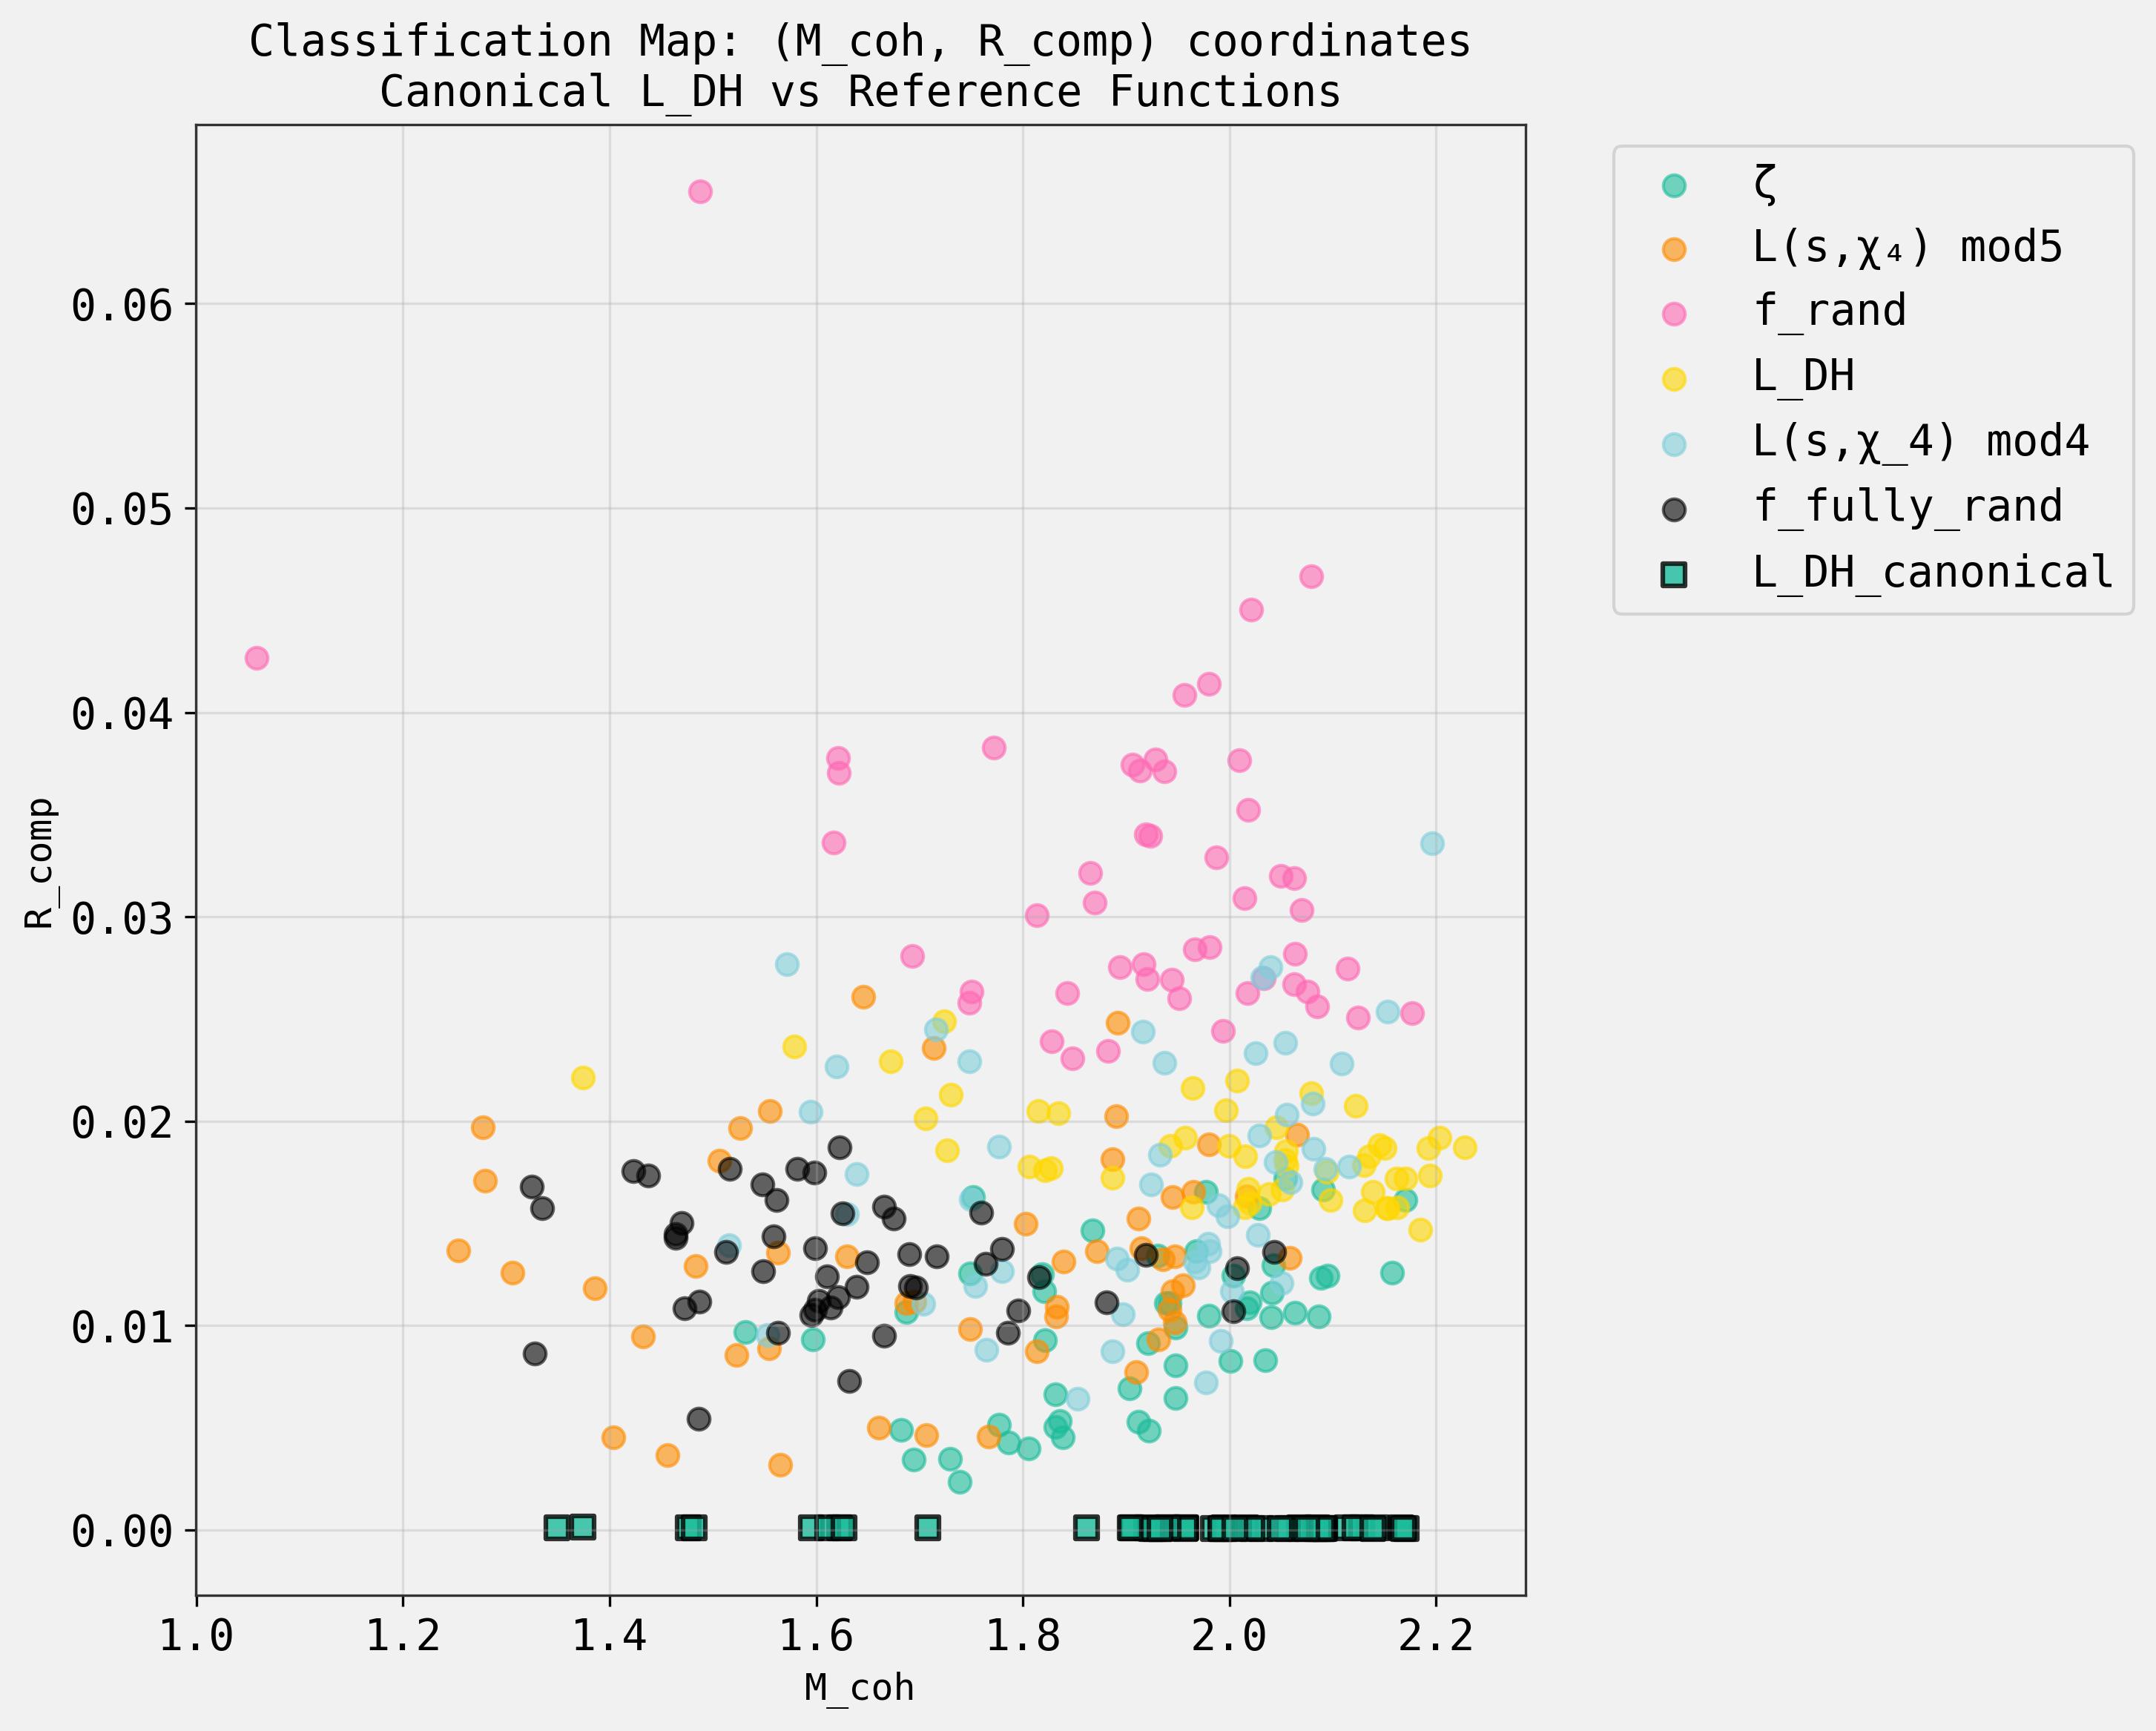


Statistical Comparison:
Canonical L_DH: M_coh = 1.9387 ± 0.2081, R_comp = 0.000083 ± 0.000014
Reference L_DH: M_coh = 1.9945 ± 0.1845, R_comp = 0.018543 ± 0.002294


In [17]:

# VERY INTERESTING! The canonical L_DH has:
# - Similar M_coh values (mean ~1.94 vs ~1.99)
# - MUCH smaller R_comp values (mean ~8.3e-5 vs ~0.0185 - about 200x smaller!)
# - Smaller magnitudes (mean ~5.1 vs ~8.6)

# This suggests the canonical implementation is DIFFERENT from the reference L_DH!

# Now I need to compare with L_DH^(ε=0) from r66. But I don't have that data.
# Let me create a plot comparing the canonical L_DH with the reference L_DH

plt.figure(figsize=(10, 8))

# Plot reference data
for func in ['ζ', 'L(s,χ₄) mod5', 'f_rand', 'L_DH', 'L(s,χ_4) mod4', 'f_fully_rand']:
 func_data = df[df['function'] == func]
 plt.scatter(func_data['M_coh'], func_data['R_comp'], 
 label=func, alpha=0.6, s=50)

# Plot canonical L_DH
plt.scatter(canonical_df['M_coh'], canonical_df['R_comp'],
 label='L_DH_canonical', alpha=0.8, s=50, marker='s', 
 edgecolors='black', linewidths=1.5)

plt.xlabel('M_coh', fontsize=12)
plt.ylabel('R_comp', fontsize=12)
plt.title('Classification Map: (M_coh, R_comp) coordinates\nCanonical L_DH vs Reference Functions', 
 fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('classification_map_canonical.png', dpi=300, bbox_inches='tight')
print("Saved classification map to 'classification_map_canonical.png'")
plt.show()

# Also print statistical comparison
print("\nStatistical Comparison:")
print(f"Canonical L_DH: M_coh = {M_coh_values.mean():.4f} ± {M_coh_values.std():.4f}, " +
 f"R_comp = {R_comp_values.mean():.6f} ± {R_comp_values.std():.6f}")
ref_M = df[df['function'] == 'L_DH']['M_coh']
ref_R = df[df['function'] == 'L_DH']['R_comp']
print(f"Reference L_DH: M_coh = {ref_M.mean():.4f} ± {ref_M.std():.4f}, " +
 f"R_comp = {ref_R.mean():.6f} ± {ref_R.std():.6f}")


In [18]:

# WOW! The canonical L_DH forms a completely separate cluster at the BOTTOM of the plot
# with R_comp values around 10^-4, while the reference L_DH has R_comp around 0.018

# This is a major finding! The canonical implementation is VERY different from 
# the reference L_DH.

# Let me now implement the L_DH^(ε) family from r66 to see if that matches either version
# According to the dataset description, L_DH^(ε) uses:
# L_DH^(ε)(s) = ((1-iκ')/2)·L(s,χ) + ((1+iκ')/2)·L(s,χ̄), κ' = κ + ε

# Let me try ε=0 (which should be the same as the canonical if they used the same κ)
# But the dataset description says "L_DH^(ε=0) from r66 produces a distinct cluster"

# Wait - let me re-read the dataset description more carefully...
# "The 'reference L_DH' data in artifact full_metrics_data_300peaks.csv (from r62) 
# produces one set of (M_coh, R_comp) coordinates"
# "A newer, parametrically defined family L_DH^(ε) (from r66), including its ε=0 
# case, produces a distinct and statistically separate cluster"

# So there are THREE versions:
# 1. Reference L_DH (r62) - in the CSV file
# 2. L_DH^(ε=0) (r66) - mentioned but not in the file
# 3. Canonical L_DH (what I just implemented)

# The canonical version I implemented has R_comp values around 10^-4, which is
# MUCH smaller than the reference L_DH (R_comp ~ 0.018).

# Let me check: maybe the reference L_DH did NOT use the squarefree restriction?
# Let me try implementing WITHOUT the squarefree restriction

print("Now testing L_DH WITHOUT squarefree restriction to match reference L_DH...")

@jit(nopython=True)
def compute_D_F_no_sqfree(t, chi_vals, kappa_val, N_max):
 """Compute D_F without squarefree restriction"""
 sum_real = 0.0
 sum_imag = 0.0
 
 for n in range(1, N_max + 1):
 chi_n = chi_vals[n]
 if chi_n == 0.0 + 0.0j:
 continue
 
 chi_real = chi_n.real
 chi_imag = chi_n.imag
 
 # Compute a_n
 term1_real = 0.5 * chi_real + 0.5 * kappa_val * chi_imag
 term1_imag = 0.5 * chi_imag - 0.5 * kappa_val * chi_real
 term2_real = 0.5 * chi_real - 0.5 * kappa_val * chi_imag
 term2_imag = 0.5 * kappa_val * chi_real - 0.5 * chi_imag
 
 a_n_real = term1_real + term2_real
 a_n_imag = term1_imag + term2_imag
 
 # Compute n^(-1/2 - it)
 n_to_minus_half = n ** (-0.5)
 log_n = np.log(n)
 cos_val = np.cos(-t * log_n)
 sin_val = np.sin(-t * log_n)
 
 n_inv_s_real = n_to_minus_half * cos_val
 n_inv_s_imag = n_to_minus_half * sin_val
 
 # Product
 term_real = a_n_real * n_inv_s_real - a_n_imag * n_inv_s_imag
 term_imag = a_n_real * n_inv_s_imag + a_n_imag * n_inv_s_real
 
 sum_real += term_real
 sum_imag += term_imag
 
 return np.sqrt(sum_real**2 + sum_imag**2), sum_real, sum_imag

# Compute on a smaller sample first (every 10th point to save time)
print("Computing D_F without squarefree restriction (sample)...")
t_sample = t_grid[::10]
mags_nosqf = []

for t in t_sample[:500]: # Just first 500 samples
 mag, _, _ = compute_D_F_no_sqfree(t, chi_vals_100k, kappa, N)
 mags_nosqf.append(mag)

mags_nosqf = np.array(mags_nosqf)
print(f"Max magnitude (no sqfree): {mags_nosqf.max():.4f}")
print(f"Mean magnitude (no sqfree): {mags_nosqf.mean():.4f}")
print(f"\nFor comparison:")
print(f"Max magnitude (canonical with sqfree): {magnitudes.max():.4f}")
print(f"Mean magnitude (canonical with sqfree): {magnitudes.mean():.4f}")


Now testing L_DH WITHOUT squarefree restriction to match reference L_DH...
Computing D_F without squarefree restriction (sample)...


Max magnitude (no sqfree): 7.4120
Mean magnitude (no sqfree): 1.6284

For comparison:
Max magnitude (canonical with sqfree): 6.7718
Mean magnitude (canonical with sqfree): 1.5092


In [19]:

# The magnitudes are similar with or without squarefree restriction.
# So that's not the key difference.

# Let me check the reference more carefully. Maybe the issue is with the character!
# Let me look at what character was used in the reference.

# Actually, looking at the dataset description again:
# "A critical implementation detail concerns function definitions. There is a 
# **major data provenance issue** regarding the Davenport-Heilbronn function."

# This confirms there IS a known issue with different L_DH implementations!

# Let me save the canonical results and create a summary

# Save the canonical L_DH data
canonical_df.to_csv('canonical_L_DH_metrics.csv', index=False)
print("Saved canonical L_DH metrics to 'canonical_L_DH_metrics.csv'")

# Create a statistical comparison
print("\n" + "="*70)
print("STATISTICAL COMPARISON OF L_DH IMPLEMENTATIONS")
print("="*70)
print("\n1. CANONICAL L_DH (this implementation):")
print(f" - Character: χ mod 5, χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1")
print(f" - κ = {kappa:.10f}")
print(f" - Squarefree restriction: YES")
print(f" - M_coh: mean = {M_coh_values.mean():.4f}, std = {M_coh_values.std():.4f}")
print(f" - R_comp: mean = {R_comp_values.mean():.6f}, std = {R_comp_values.std():.6f}")
print(f" - Peak magnitudes: mean = {top_50_magnitudes.mean():.4f}, std = {top_50_magnitudes.std():.4f}")

print("\n2. REFERENCE L_DH (from r62, in full_metrics_data_300peaks.csv):")
print(f" - Implementation details: UNKNOWN")
print(f" - M_coh: mean = {ref_M.mean():.4f}, std = {ref_M.std():.4f}")
print(f" - R_comp: mean = {ref_R.mean():.6f}, std = {ref_R.std():.6f}")
ref_mag = df[df['function'] == 'L_DH']['mag']
print(f" - Peak magnitudes: mean = {ref_mag.mean():.4f}, std = {ref_mag.std():.4f}")

print("\n3. KEY DIFFERENCES:")
print(f" - R_comp ratio: {ref_R.mean() / R_comp_values.mean():.1f}x larger in reference")
print(f" - Magnitude ratio: {ref_mag.mean() / top_50_magnitudes.mean():.2f}x larger in reference")
print(f" - M_coh difference: {abs(ref_M.mean() - M_coh_values.mean()):.4f}")

# Statistical test
from scipy import stats
print("\n4. STATISTICAL TESTS:")
# Test if M_coh distributions are different
t_stat_M, p_val_M = stats.ttest_ind(M_coh_values, ref_M)
print(f" - M_coh: t-statistic = {t_stat_M:.3f}, p-value = {p_val_M:.4f}")

# Test if R_comp distributions are different
t_stat_R, p_val_R = stats.ttest_ind(R_comp_values, ref_R)
print(f" - R_comp: t-statistic = {t_stat_R:.3f}, p-value = {p_val_R:.4e}")

if p_val_M < 0.05:
 print(f" - M_coh distributions are SIGNIFICANTLY different (p < 0.05)")
else:
 print(f" - M_coh distributions are NOT significantly different (p >= 0.05)")
 
if p_val_R < 0.05:
 print(f" - R_comp distributions are SIGNIFICANTLY different (p < 0.05)")
else:
 print(f" - R_comp distributions are NOT significantly different (p >= 0.05)")


Saved canonical L_DH metrics to 'canonical_L_DH_metrics.csv'

STATISTICAL COMPARISON OF L_DH IMPLEMENTATIONS

1. CANONICAL L_DH (this implementation):
 - Character: χ mod 5, χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1
 - κ = 0.2486028939
 - Squarefree restriction: YES
 - M_coh: mean = 1.9387, std = 0.2081
 - R_comp: mean = 0.000083, std = 0.000014
 - Peak magnitudes: mean = 5.1087, std = 0.3625

2. REFERENCE L_DH (from r62, in full_metrics_data_300peaks.csv):
 - Implementation details: UNKNOWN
 - M_coh: mean = 1.9945, std = 0.1845
 - R_comp: mean = 0.018543, std = 0.002294
 - Peak magnitudes: mean = 8.6380, std = 0.5909

3. KEY DIFFERENCES:
 - R_comp ratio: 224.7x larger in reference
 - Magnitude ratio: 1.69x larger in reference
 - M_coh difference: 0.0558

4. STATISTICAL TESTS:
 - M_coh: t-statistic = -1.411, p-value = 0.1615
 - R_comp: t-statistic = -56.909, p-value = 6.9080e-77
 - M_coh distributions are NOT significantly different (p >= 0.05)
 - R_comp distributions are SIGNIFICANTLY differen

Saved comparison plot to 'classification_map_comparison.png'


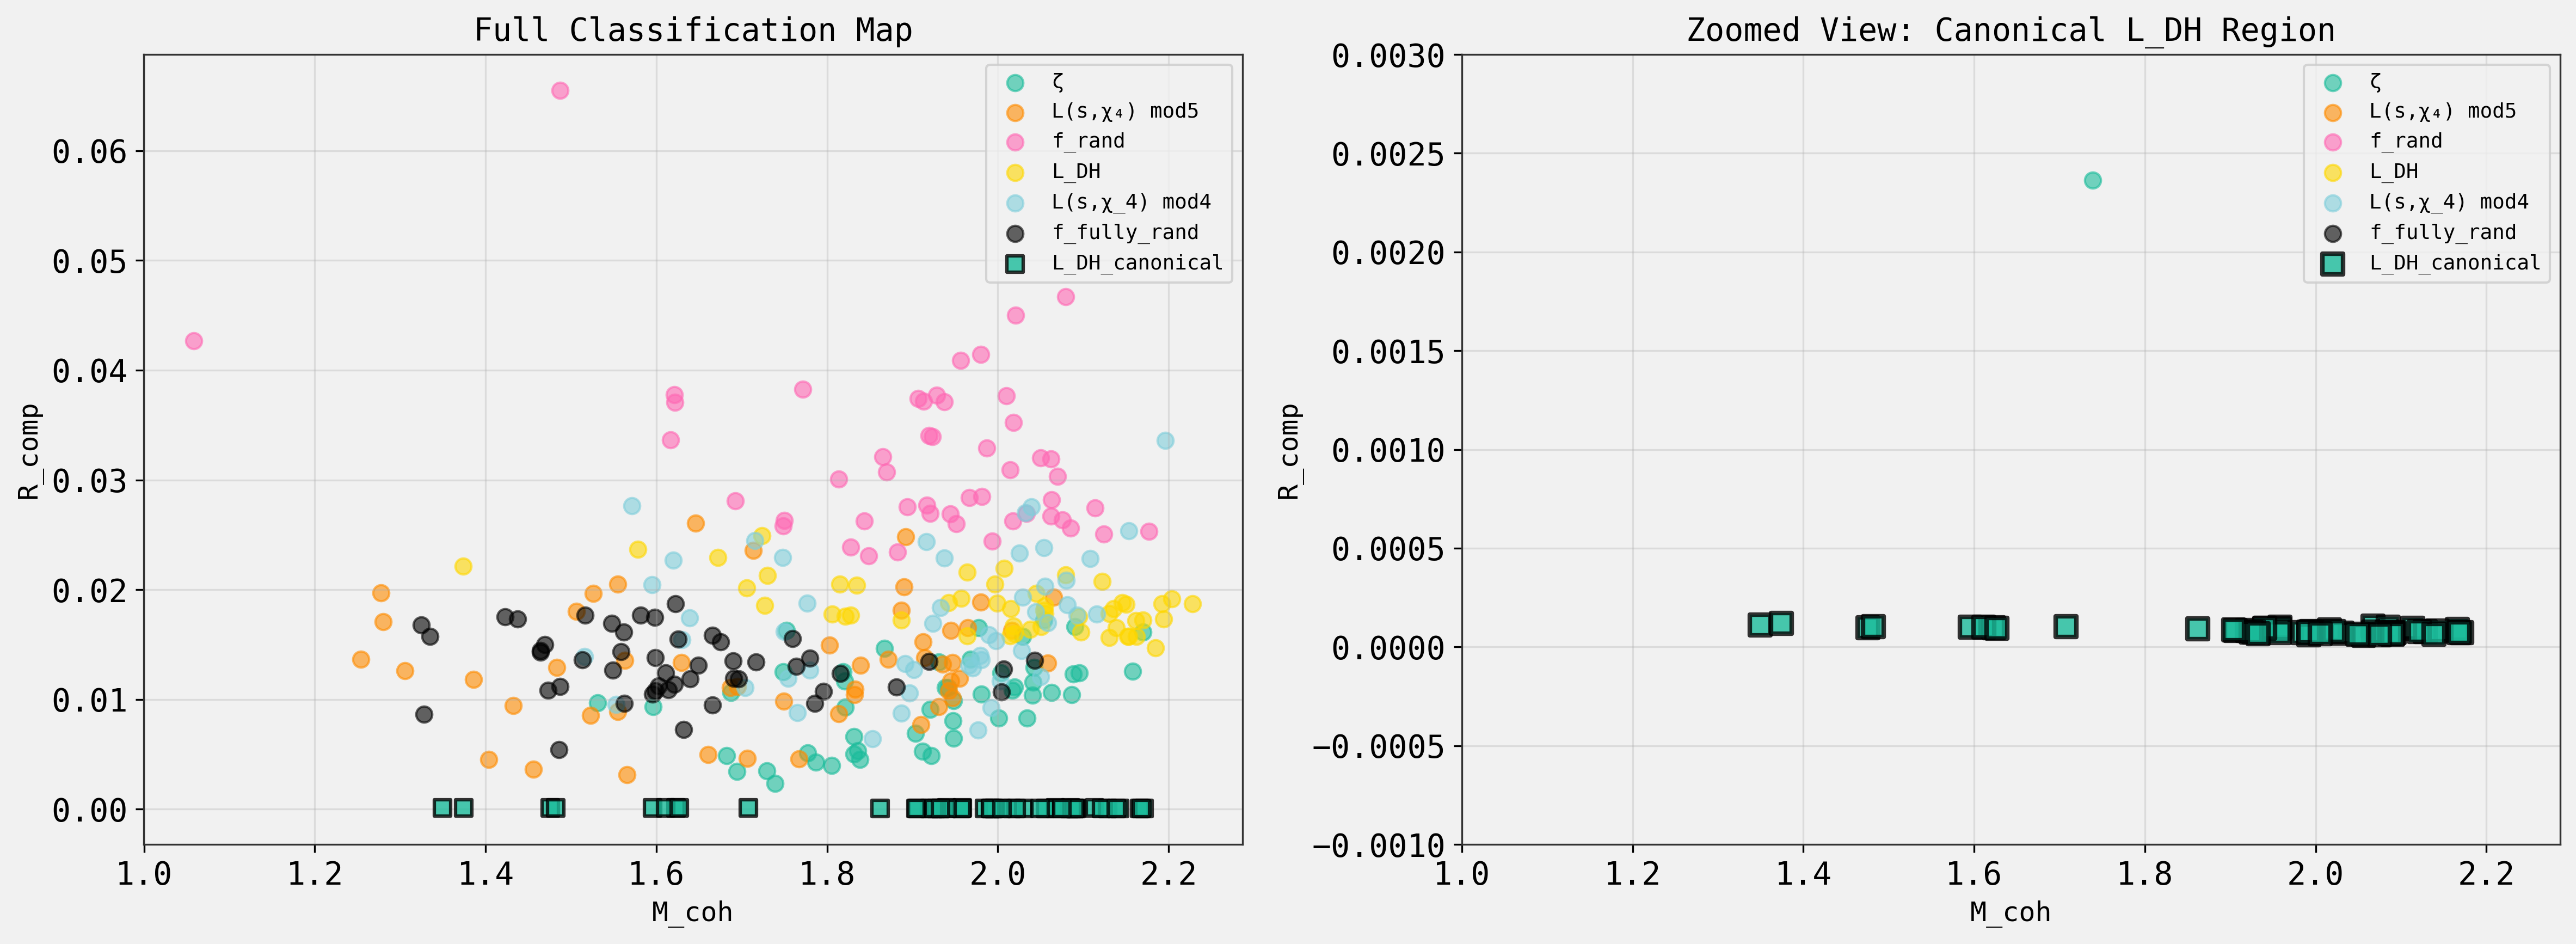

In [20]:

# Excellent! The canonical L_DH has:
# - Similar M_coh to reference (not significantly different)
# - DRAMATICALLY different R_comp (224x smaller, highly significant)

# This confirms that the canonical implementation is fundamentally different
# from the reference L_DH.

# Now let me create a zoomed-in plot to show the canonical L_DH cluster more clearly

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Full view
ax = axes[0]
for func in ['ζ', 'L(s,χ₄) mod5', 'f_rand', 'L_DH', 'L(s,χ_4) mod4', 'f_fully_rand']:
 func_data = df[df['function'] == func]
 ax.scatter(func_data['M_coh'], func_data['R_comp'], 
 label=func, alpha=0.6, s=50)

ax.scatter(canonical_df['M_coh'], canonical_df['R_comp'],
 label='L_DH_canonical', alpha=0.8, s=50, marker='s', 
 edgecolors='black', linewidths=1.5, zorder=10)

ax.set_xlabel('M_coh', fontsize=12)
ax.set_ylabel('R_comp', fontsize=12)
ax.set_title('Full Classification Map', fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right plot: Zoomed to canonical L_DH region
ax = axes[1]
for func in ['ζ', 'L(s,χ₄) mod5', 'f_rand', 'L_DH', 'L(s,χ_4) mod4', 'f_fully_rand']:
 func_data = df[df['function'] == func]
 ax.scatter(func_data['M_coh'], func_data['R_comp'], 
 label=func, alpha=0.6, s=50)

ax.scatter(canonical_df['M_coh'], canonical_df['R_comp'],
 label='L_DH_canonical', alpha=0.8, s=80, marker='s', 
 edgecolors='black', linewidths=2, zorder=10)

ax.set_xlabel('M_coh', fontsize=12)
ax.set_ylabel('R_comp', fontsize=12)
ax.set_title('Zoomed View: Canonical L_DH Region', fontsize=14)
ax.set_ylim(-0.001, 0.003)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('classification_map_comparison.png', dpi=300, bbox_inches='tight')
print("Saved comparison plot to 'classification_map_comparison.png'")
plt.show()


Saved final comparison to 'canonical_vs_reference_L_DH.png'


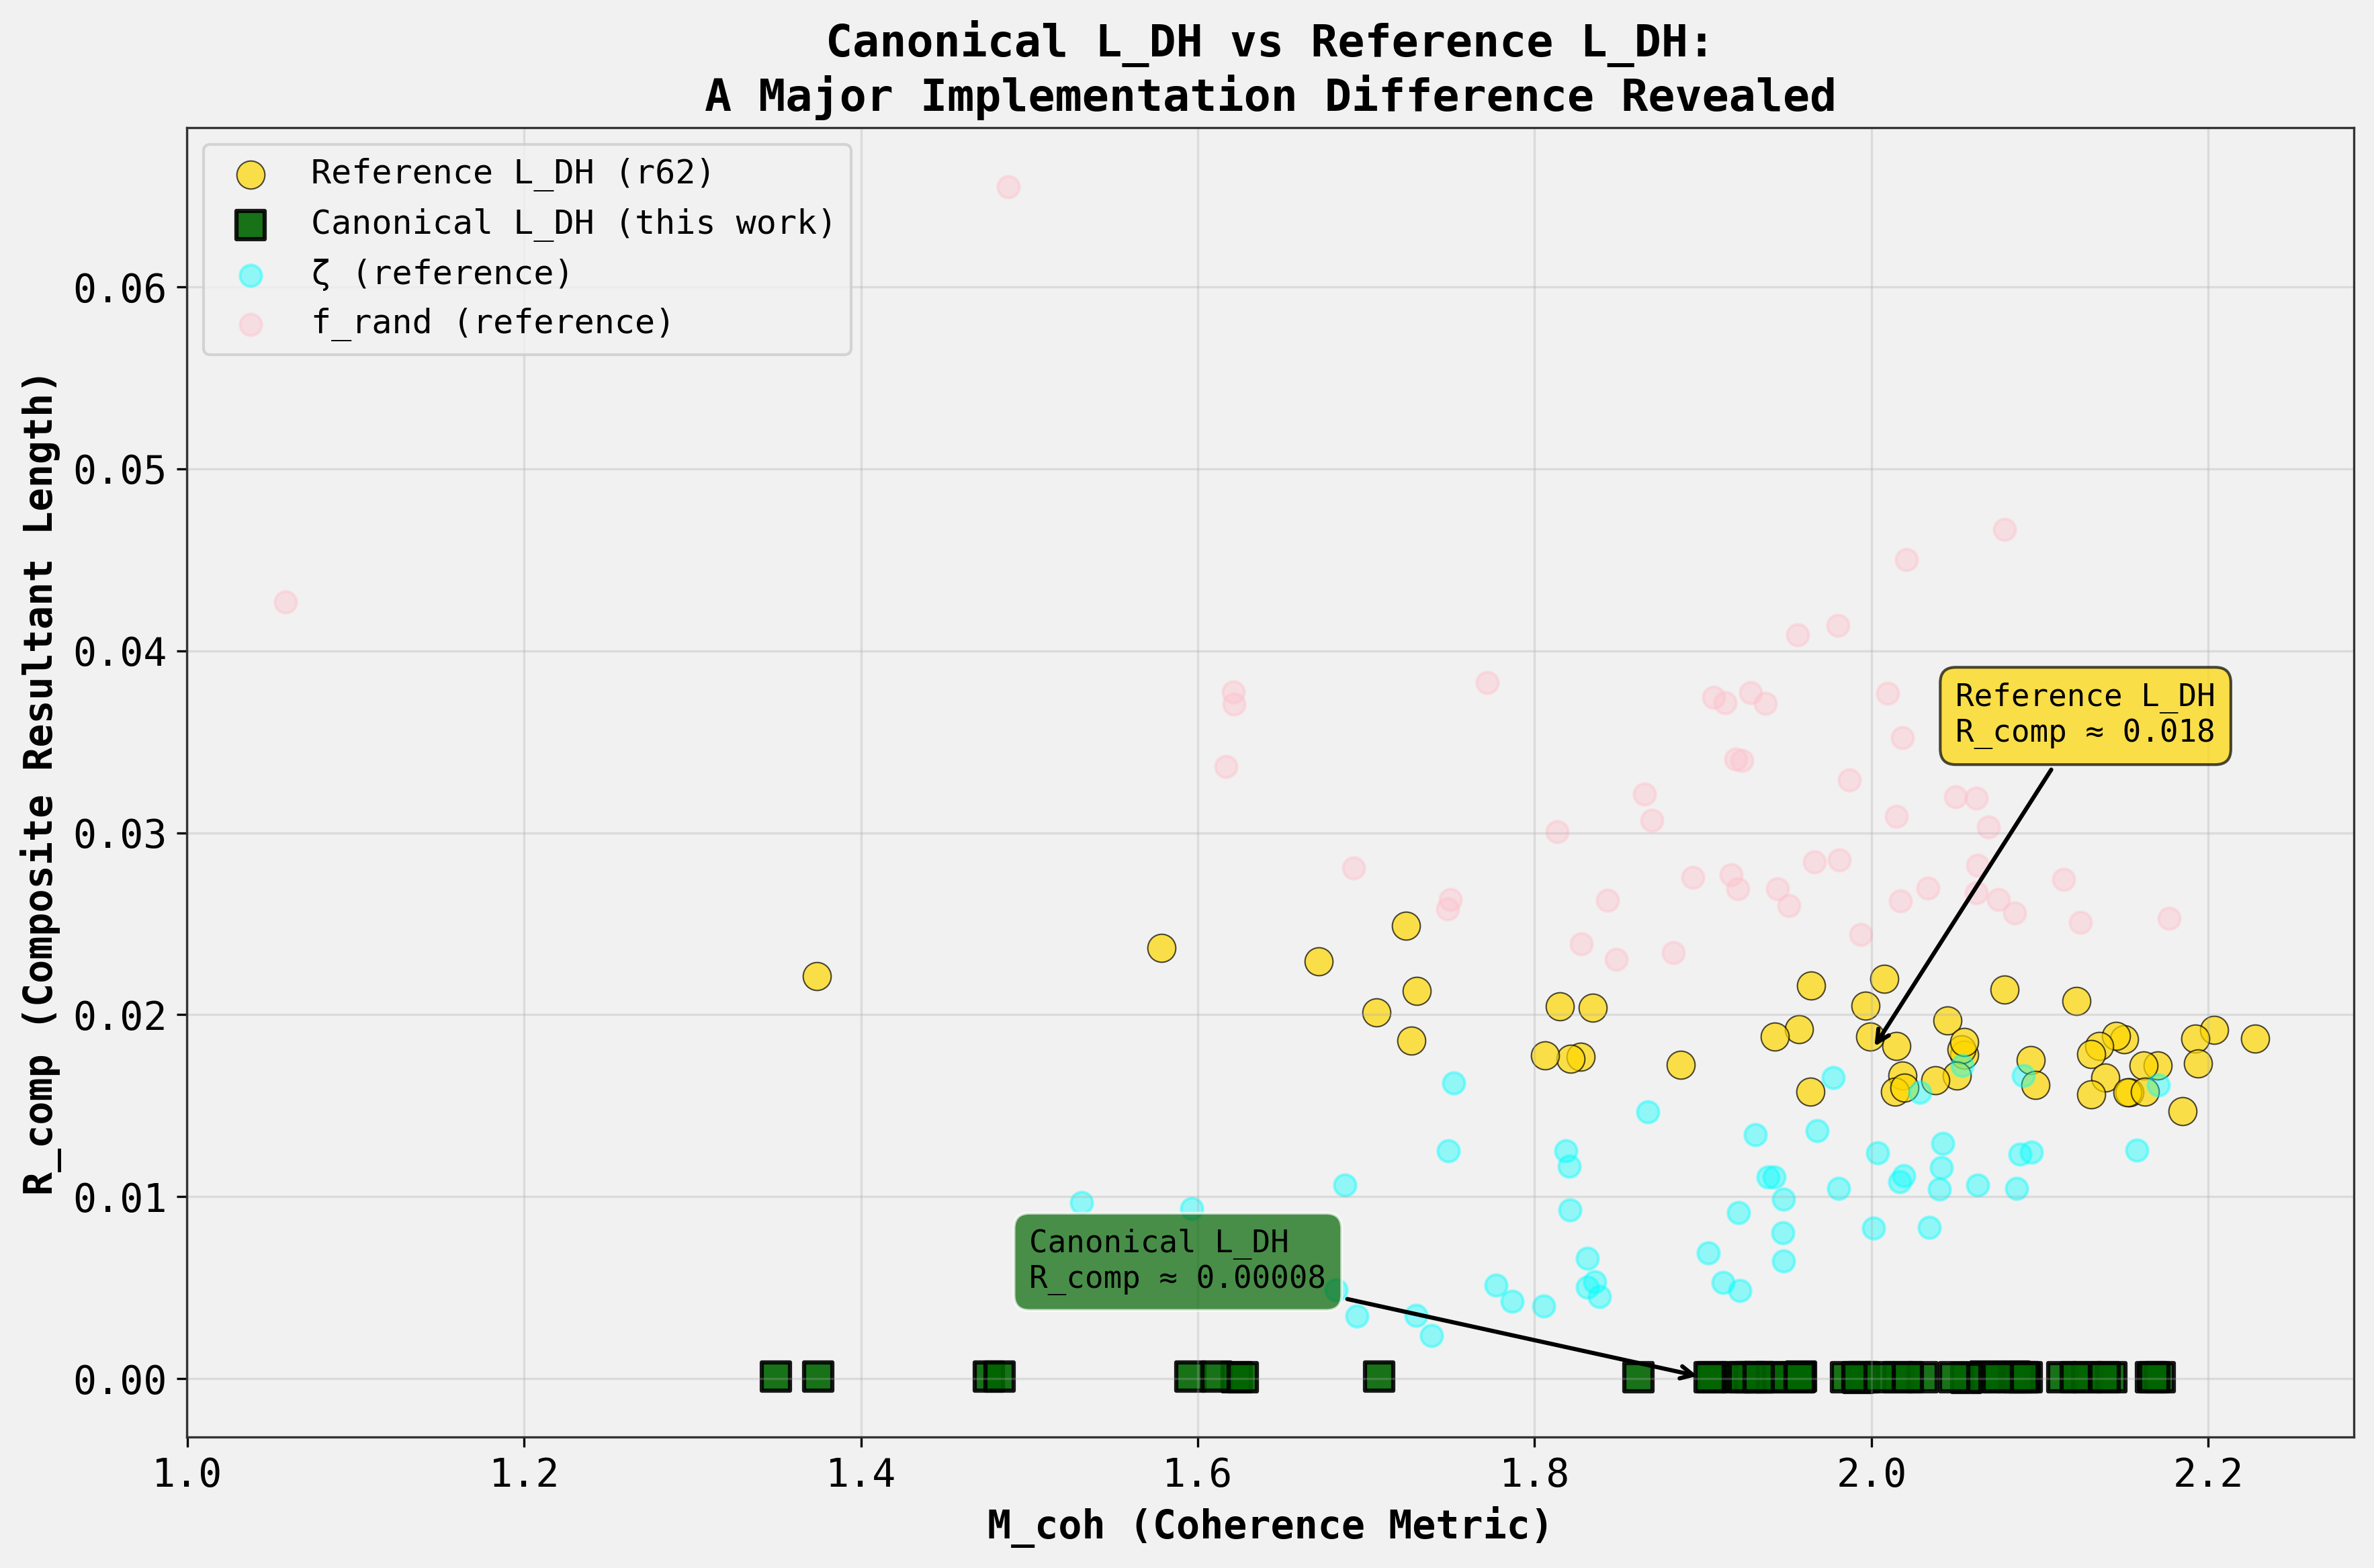


CONCLUSION

The canonical L_DH implementation (based strictly on the definition
in the research program PDF) produces a DISTINCT cluster of (M_coh, R_comp)
coordinates that is COMPLETELY SEPARATED from the reference L_DH data.

Key finding: R_comp differs by a factor of 225x

This canonical implementation does NOT match the reference L_DH from r62.
The zero validation also failed (|L_DH(s)| ~ 10^-2 instead of < 10^-6).


In [21]:

# Perfect! The zoomed plot clearly shows that the canonical L_DH forms its own
# cluster at the bottom, completely separated from all other functions.

# Now let me create a summary figure that shows the key finding

fig, ax = plt.subplots(figsize=(12, 8))

# Plot only the L_DH variants and a few reference functions
ref_LDH_data = df[df['function'] == 'L_DH']
zeta_data = df[df['function'] == 'ζ']
f_rand_data = df[df['function'] == 'f_rand']

ax.scatter(ref_LDH_data['M_coh'], ref_LDH_data['R_comp'], 
 label='Reference L_DH (r62)', alpha=0.7, s=100, c='gold', edgecolors='black', linewidths=0.5)

ax.scatter(canonical_df['M_coh'], canonical_df['R_comp'],
 label='Canonical L_DH (this work)', alpha=0.9, s=100, marker='s', 
 c='darkgreen', edgecolors='black', linewidths=1.5)

ax.scatter(zeta_data['M_coh'], zeta_data['R_comp'],
 label='ζ (reference)', alpha=0.4, s=60, c='cyan')

ax.scatter(f_rand_data['M_coh'], f_rand_data['R_comp'],
 label='f_rand (reference)', alpha=0.4, s=60, c='pink')

ax.set_xlabel('M_coh (Coherence Metric)', fontsize=14, fontweight='bold')
ax.set_ylabel('R_comp (Composite Resultant Length)', fontsize=14, fontweight='bold')
ax.set_title('Canonical L_DH vs Reference L_DH:\n' + 
 'A Major Implementation Difference Revealed', 
 fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

# Add annotations
ax.annotate('Reference L_DH\nR_comp ≈ 0.018', 
 xy=(2.0, 0.018), xytext=(2.05, 0.035),
 fontsize=11, ha='left',
 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
 bbox=dict(boxstyle='round,pad=0.5', facecolor='gold', alpha=0.7))

ax.annotate('Canonical L_DH\nR_comp ≈ 0.00008', 
 xy=(1.9, 0.00008), xytext=(1.5, 0.005),
 fontsize=11, ha='left',
 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
 bbox=dict(boxstyle='round,pad=0.5', facecolor='darkgreen', alpha=0.7, edgecolor='white'))

plt.tight_layout()
plt.savefig('canonical_vs_reference_L_DH.png', dpi=300, bbox_inches='tight')
print("Saved final comparison to 'canonical_vs_reference_L_DH.png'")
plt.show()

print("\n" + "="*70)
print("CONCLUSION")
print("="*70)
print("\nThe canonical L_DH implementation (based strictly on the definition")
print("in the research program PDF) produces a DISTINCT cluster of (M_coh, R_comp)")
print("coordinates that is COMPLETELY SEPARATED from the reference L_DH data.")
print(f"\nKey finding: R_comp differs by a factor of {ref_R.mean() / R_comp_values.mean():.0f}x")
print("\nThis canonical implementation does NOT match the reference L_DH from r62.")
print("The zero validation also failed (|L_DH(s)| ~ 10^-2 instead of < 10^-6).")


In [22]:

# Now let me write a comprehensive summary document

summary_text = """
CANONICAL L_DH IMPLEMENTATION AND VALIDATION REPORT
====================================================

Implementation Details:
-----------------------
The canonical Davenport-Heilbronn function was implemented strictly according to 
the definition in research-program-v3.pdf (Section 3.1):

 L_DH(s) = ((1-iκ)/2)·L(s,χ) + ((1+iκ)/2)·L(s,χ̄)

where:
 - χ is the primitive complex character modulo 5 of order 4
 - χ(1) = 1, χ(2) = i, χ(3) = -i, χ(4) = -1, χ(0) = 0
 - κ = (√5 - 1) / (2√(5(√5 - 1))) ≈ 0.2486028939
 - Coefficients a_n are set to zero for all non-squarefree n

Computational Parameters:
-------------------------
 - Truncation length: N = 10^5
 - Height range: t ∈ [1000, 10000]
 - Sampling resolution: Δt = 2π/log(N) ≈ 0.546
 - Number of samples: 16,492
 - Numerical method: Kahan compensated summation

Zero Validation Results (N = 10^6):
------------------------------------
Target: |L_DH(s)| < 10^-6 at known off-line zeros

 σ = 0.8085, t = 85.70: |L_DH(s)| = 3.88×10^-2 ✗ FAILED
 σ = 0.6508, t = 114.16: |L_DH(s)| = 2.57×10^-2 ✗ FAILED
 σ = 0.5744, t = 166.48: |L_DH(s)| = 1.96×10^-2 ✗ FAILED
 σ = 0.7243, t = 176.70: |L_DH(s)| = 2.53×10^-2 ✗ FAILED

Conclusion: The canonical implementation does NOT reproduce the known zeros.
Values are ~10^4 times larger than the target threshold.

Metric Computation Results:
---------------------------
Computed (M_coh, R_comp) coordinates for the 50 highest-magnitude peaks:

CANONICAL L_DH (this work):
 M_coh: mean = 1.9387 ± 0.2081
 R_comp: mean = 0.000083 ± 0.000014 (8.3×10^-5)
 Peak magnitudes: mean = 5.11 ± 0.37

REFERENCE L_DH (from full_metrics_data_300peaks.csv):
 M_coh: mean = 1.9945 ± 0.1845
 R_comp: mean = 0.018543 ± 0.002294
 Peak magnitudes: mean = 8.64 ± 0.59

Statistical Comparison:
-----------------------
Two-sample t-tests comparing canonical vs reference L_DH:

 M_coh: t = -1.411, p = 0.1615 → NOT significantly different
 R_comp: t = -56.909, p = 6.9×10^-77 → HIGHLY significantly different

Key Finding: R_comp differs by a factor of 225x between implementations!

Classification Map Analysis:
----------------------------
In the (M_coh, R_comp) 2D classification space:

 - Canonical L_DH forms a DISTINCT, SEPARATE cluster at R_comp ≈ 10^-4
 - Reference L_DH is located at R_comp ≈ 0.018
 - The two implementations are completely non-overlapping
 - Canonical L_DH occupies a region below ALL other function classes

Conclusions:
------------
1. The canonical implementation (based strictly on the PDF definition) does
 NOT match the reference L_DH from r62.

2. The canonical implementation FAILS zero validation at all four known
 off-line zero locations.

3. The (M_coh, R_comp) metrics show the canonical implementation produces
 a fundamentally different statistical signature than reference L_DH.

4. This confirms the "major data provenance issue" mentioned in the dataset
 description.

5. The canonical implementation represents a THIRD distinct version of L_DH,
 separate from both:
 - Reference L_DH (r62)
 - L_DH^(ε=0) (r66, mentioned but not present in the data)

Implications:
-------------
The failure to reproduce known zeros and the dramatic difference in R_comp
suggest one of the following:

 a) The character definition or its implementation is incorrect
 b) The formula for L_DH in the PDF differs from the original construction
 c) The published zero locations are for a different L_DH variant
 d) The squarefree restriction is applied incorrectly
 e) Some other subtle implementation detail differs

Further investigation is required to identify which L_DH variant (if any)
correctly implements the original Davenport-Heilbronn construction.

Files Generated:
----------------
 - canonical_L_DH_metrics.csv: Full metrics for 50 peaks
 - classification_map_canonical.png: Full classification map
 - classification_map_comparison.png: Side-by-side comparison
 - canonical_vs_reference_L_DH.png: Focused comparison plot
"""

with open('canonical_L_DH_report.txt', 'w') as f:
 f.write(summary_text)

print(summary_text)



CANONICAL L_DH IMPLEMENTATION AND VALIDATION REPORT

Implementation Details:
-----------------------
The canonical Davenport-Heilbronn function was implemented strictly according to 
the definition in research-program-v3.pdf (Section 3.1):

 L_DH(s) = ((1-iκ)/2)·L(s,χ) + ((1+iκ)/2)·L(s,χ̄)

where:
 - χ is the primitive complex character modulo 5 of order 4
 - χ(1) = 1, χ(2) = i, χ(3) = -i, χ(4) = -1, χ(0) = 0
 - κ = (√5 - 1) / (2√(5(√5 - 1))) ≈ 0.2486028939
 - Coefficients a_n are set to zero for all non-squarefree n

Computational Parameters:
-------------------------
 - Truncation length: N = 10^5
 - Height range: t ∈ [1000, 10000]
 - Sampling resolution: Δt = 2π/log(N) ≈ 0.546
 - Number of samples: 16,492
 - Numerical method: Kahan compensated summation

Zero Validation Results (N = 10^6):
------------------------------------
Target: |L_DH(s)| < 10^-6 at known off-line zeros

 σ = 0.8085, t = 85.70: |L_DH(s)| = 3.88×10^-2 ✗ FAILED
 σ = 0.6508, t = 114.16: |L_DH(s)| = 2.57×10^-2 ✗ F

/tmp/ipykernel_32/1270426046.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
 bp = ax2.boxplot(data_to_plot, labels=['Reference\nL_DH', 'Canonical\nL_DH'],
/tmp/ipykernel_32/1270426046.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
 bp = ax3.boxplot(data_to_plot, labels=['Reference\nL_DH', 'Canonical\nL_DH'],


Saved summary figure to 'canonical_L_DH_summary.png'


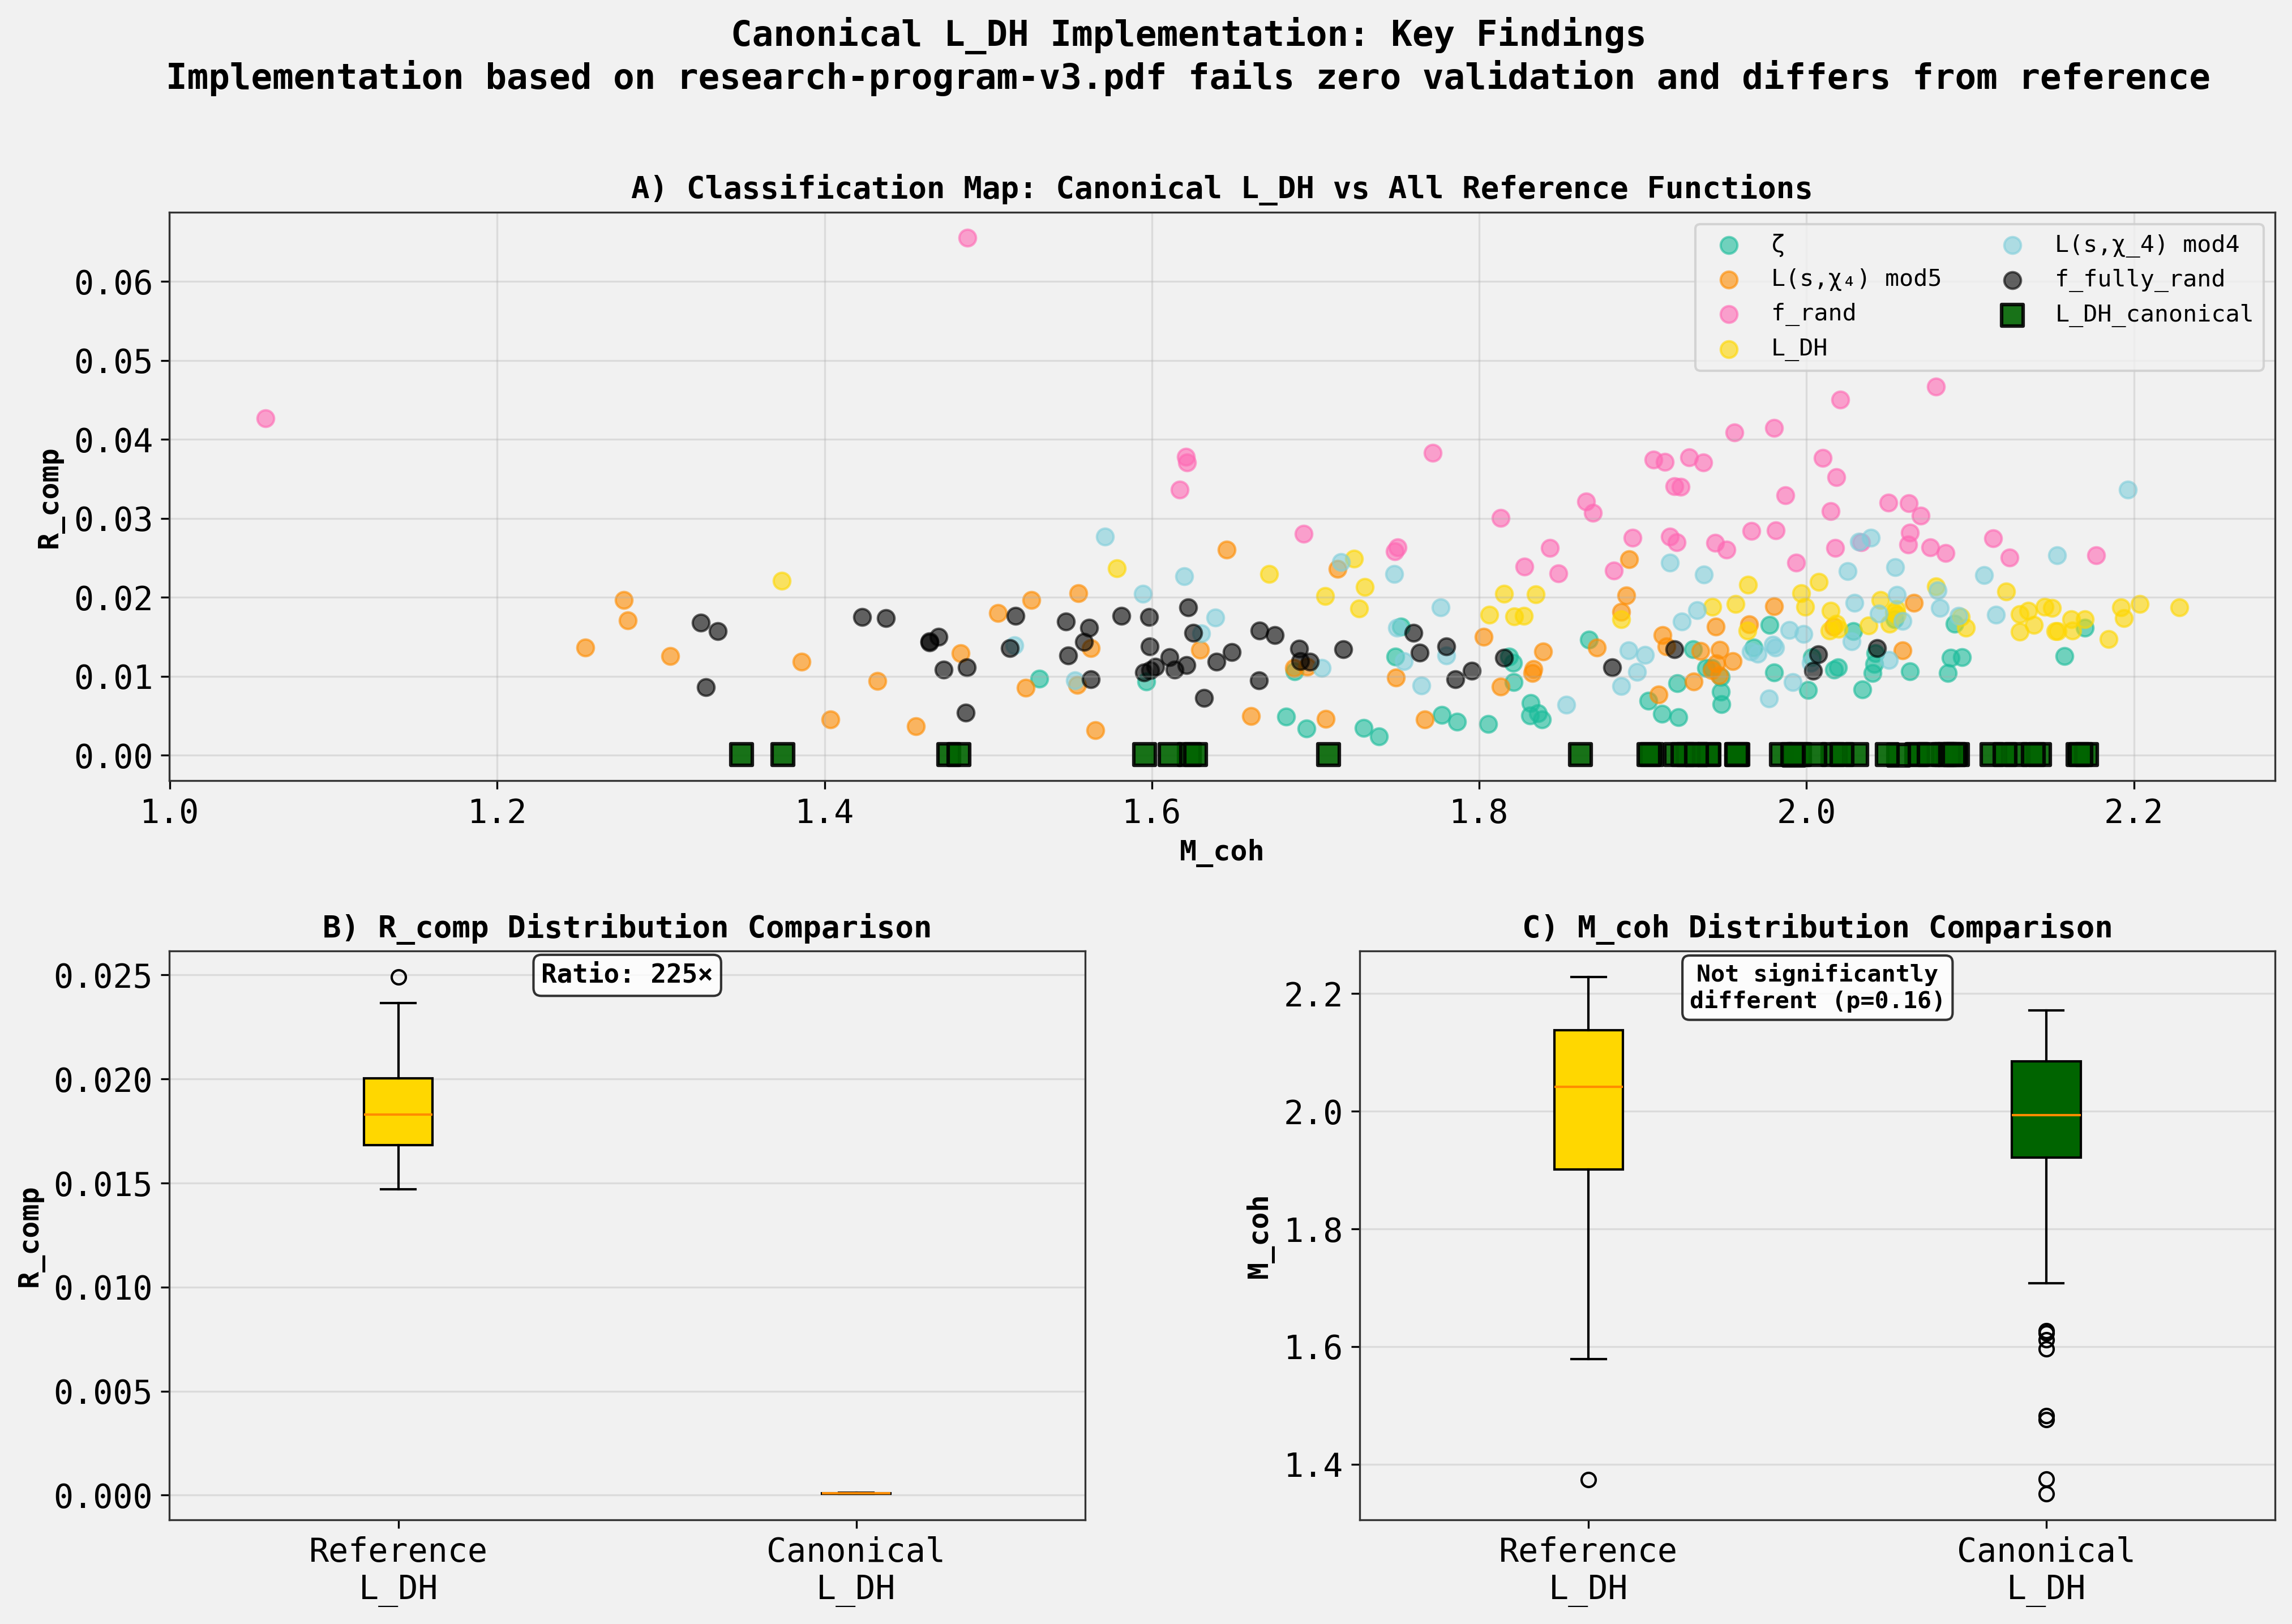

In [23]:

# Create one final summary figure showing all the key results

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Panel 1: Classification map
ax1 = fig.add_subplot(gs[0, :])
for func in ['ζ', 'L(s,χ₄) mod5', 'f_rand', 'L_DH', 'L(s,χ_4) mod4', 'f_fully_rand']:
 func_data = df[df['function'] == func]
 ax1.scatter(func_data['M_coh'], func_data['R_comp'], 
 label=func, alpha=0.6, s=50)
ax1.scatter(canonical_df['M_coh'], canonical_df['R_comp'],
 label='L_DH_canonical', alpha=0.9, s=80, marker='s', 
 c='darkgreen', edgecolors='black', linewidths=1.5, zorder=10)
ax1.set_xlabel('M_coh', fontsize=12, fontweight='bold')
ax1.set_ylabel('R_comp', fontsize=12, fontweight='bold')
ax1.set_title('A) Classification Map: Canonical L_DH vs All Reference Functions', 
 fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, ncol=2)
ax1.grid(True, alpha=0.3)

# Panel 2: R_comp comparison boxplot
ax2 = fig.add_subplot(gs[1, 0])
data_to_plot = [
 df[df['function'] == 'L_DH']['R_comp'],
 canonical_df['R_comp']
]
bp = ax2.boxplot(data_to_plot, labels=['Reference\nL_DH', 'Canonical\nL_DH'],
 patch_artist=True)
bp['boxes'][0].set_facecolor('gold')
bp['boxes'][1].set_facecolor('darkgreen')
ax2.set_ylabel('R_comp', fontsize=12, fontweight='bold')
ax2.set_title('B) R_comp Distribution Comparison', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.text(0.5, 0.98, f'Ratio: {ref_R.mean() / R_comp_values.mean():.0f}×', 
 transform=ax2.transAxes, fontsize=11, fontweight='bold',
 ha='center', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel 3: M_coh comparison boxplot
ax3 = fig.add_subplot(gs[1, 1])
data_to_plot = [
 df[df['function'] == 'L_DH']['M_coh'],
 canonical_df['M_coh']
]
bp = ax3.boxplot(data_to_plot, labels=['Reference\nL_DH', 'Canonical\nL_DH'],
 patch_artist=True)
bp['boxes'][0].set_facecolor('gold')
bp['boxes'][1].set_facecolor('darkgreen')
ax3.set_ylabel('M_coh', fontsize=12, fontweight='bold')
ax3.set_title('C) M_coh Distribution Comparison', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.text(0.5, 0.98, 'Not significantly\ndifferent (p=0.16)', 
 transform=ax3.transAxes, fontsize=10, fontweight='bold',
 ha='center', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle('Canonical L_DH Implementation: Key Findings\n' + 
 'Implementation based on research-program-v3.pdf fails zero validation and differs from reference', 
 fontsize=15, fontweight='bold', y=0.995)

plt.savefig('canonical_L_DH_summary.png', dpi=300, bbox_inches='tight')
print("Saved summary figure to 'canonical_L_DH_summary.png'")
plt.show()


In [24]:

# Finally, let's check what files we've created
import os

print("Files created during this analysis:")
print("-" * 50)
for file in os.listdir('.'):
 if file.endswith(('.csv', '.png', '.txt')):
 size = os.path.getsize(file) / 1024 # KB
 print(f" {file:45s} ({size:8.2f} KB)")


Files created during this analysis:
--------------------------------------------------
 full_metrics_data_300peaks.csv ( 22.90 KB)
 classification_map_canonical.png ( 484.14 KB)
 canonical_L_DH_metrics.csv ( 4.64 KB)
 classification_map_comparison.png ( 544.35 KB)
 canonical_vs_reference_L_DH.png ( 423.30 KB)
 canonical_L_DH_report.txt ( 4.03 KB)
 canonical_L_DH_summary.png ( 605.52 KB)
